Prototyping notebook for composite viscoelasticity.

Merged into github repository `ve-composite`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def nu_KG(K, G):
  ''' Compute poisson ratio as function of K, G. '''
  nu = (3 * K - 2 * G) / (2 * (3 *K + G))
  return nu

def G_spher_incl(nu1, G1, G2, phi2):
  ''' Spherical inclusion shear modulus for small volume fraction phi2
    Christensen 1979, Chen and Lakes J. Mat. Sci. 

    Taylor expansion of G_Hashin lower bound, or from considering a single
    spherical inclusion subject to remote stresses at infinity.
  '''
  num = 15 * (1 - nu1) * (1 - G2 / G1) * (phi2)
  denom = 7 - 5 * nu1 + 2 * (4 - 5 * nu1 ) * G2 / G1
  return G1 * (1 - num/denom)

def G_spher_incl2(K1, G1, G2, phi2):
  ''' From Hashin 1983 Analysis of composites--a survey.
  Based on Eshelby strain
  '''
  denom = 9 * K1 + 8 * G1 + 6 * (K1 + 2*G1) * G2 / G1
  return G1 + (G2 - G1) * 5 * (3 * K1 + 4 * G1) * phi2 / denom

def K_spher_incl2(K1, G1, K2, phi2):
  ''' From Hashin 1983 Analysis of composites--a survey
  '''
  return K1 + (K2 - K1) * (3 * K1 + 4 * G1) / (3 * K2 + 4 * G1) * phi2

def G_Voigt_laminate(G1, G2, phi2):
  return (1-phi2) * G1 + phi2 * G2

def K_Voigt_laminate(K1, K2, phi2):
  return (1-phi2) * K1 + phi2 * K2

def G_Reuss_laminate(G1, G2, phi2):
  return 1 / ((1-phi2) / G1 + phi2 / G2)

def K_Reuss_laminate(K1, K2, phi2):
  return 1 / ((1-phi2) / K1 + phi2 / K2)

def G_platelet_incl(K2, G1, G2, phi2):
  ''' Dilute platelet inclusion shear modulus for small volume fraction phi2
    Christensen 1979, Chen and Lakes J. Mat. Sci.  Platelets are randomly
    oriented.
  '''
  _f1 = (9*K2 + 4*(G1 + 2*G2)) / (K2 + (4/3)*G2) + 6 * G1 / G2
  return G1 + phi2 * (G2 - G1) / 15 * _f1



def G_Hashin(G1, G2, K1, K2, phi2) -> tuple:
  ''' Hashin bounds on composite shear modulus '''

  def bound_qty(G1, G2, K2, phi1):
    phi2 = 1 - phi1
    return (G2 + phi1 / (1 / (G1-G2)
      + 6 * (K2 + 2 * G2) * phi2 / (5 * (3 * K2 + 4 * G2) * G2)))
  
  G_bounds = np.stack([bound_qty(G1, G2, K2, 1 - phi2), bound_qty(G2, G1, K1, phi2)], axis=0)
  return np.array((G_bounds.min(axis=0), G_bounds.max(axis=0),))




Text(0.5, 0, 'Vol frac inclusions')

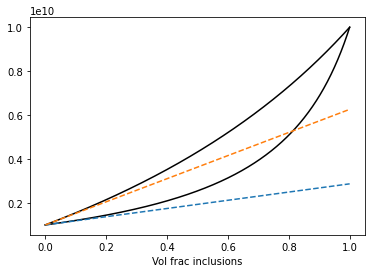

In [3]:
K1 = 10e9
K2 = 30e9
G1 = 1e9
G2 = 10e9
Gspher_phi = lambda phi: G_spher_incl(nu_KG(K1, G1), G1, G2, phi)
Gspher_phi = lambda phi: G_spher_incl2(K1, G1, G2, phi)

Gplatelet_phi = lambda phi: G_platelet_incl(K2, G1, G2, phi)


phi_range = np.linspace(0, 1, 1000)
Gmin, Gmax = G_Hashin(G1, G2, K1, K2, phi_range)

plt.plot(phi_range, Gmin, 'k')
plt.plot(phi_range, Gmax, 'k')

plt.plot(phi_range, Gspher_phi(phi_range), '--', label="spher")
plt.plot(phi_range, Gplatelet_phi(phi_range), '--', label="plate")
plt.xlabel("Vol frac inclusions")


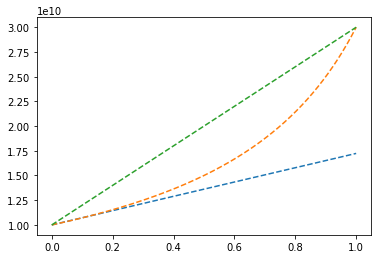

In [4]:
Kspher_phi = lambda phi: K_spher_incl2(K1, G1, K2, phi)
KReuss_phi = lambda phi: K_Reuss_laminate(K1, K2, phi)
KVoigt_phi = lambda phi: K_Voigt_laminate(K1, K2, phi)
K_Voigt_laminate
plt.plot(phi_range, Kspher_phi(phi_range), '--', label="spher")
plt.plot(phi_range, KReuss_phi(phi_range), '--', label="reuss")
plt.plot(phi_range, KVoigt_phi(phi_range), '--', label="voigt")


* For low vol frac: two end-member estimates of complex modulus as a function of vol frac, thus requiring an estimate of intrusive-extrusive ratio
* Bounds on the stiffness-loss curves are not rigorous; is there a HS-type bound for viscoelastic materials based on a time-dependent energy functional?

In [5]:
Gspher_phi = lambda phi: G_spher_incl2(K1, G1, G2, phi)
Kspher_phi = lambda phi: K_spher_incl2(K1, G1, K2, phi)

# Q: complex part of composite K as a function of complex G1, G2?

K_spher_incl2(K1, G1*(1+.001j), K2, 0.1)

(10723404257.630775+54323.223079541465j)

This is a stiffness-loss map for a pure phase:


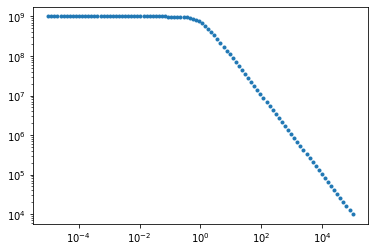

In [6]:
# Maxwell material mapping

def mod2complex(De):
  ''' Mapping from elastic modulus to complex form as function of
   Deborah number De == freq * viscosity / modulus '''
  return (De*De + De * 1j) / (De*De + 1)

De_vec = np.logspace(-5, 5, 100)
G_complex = G1 * mod2complex(De_vec)
plt.loglog(np.imag(G_complex) / np.real(G_complex), np.abs(G_complex), '.')

print("This is a stiffness-loss map for a pure phase:")

Bulk modulus

In [7]:
def plot_stiffness_loss(z, K1):
  plt.semilogx(np.imag(z) / np.real(z), np.abs(z) / K1, '.')
  
  plt.xlabel(r"$\tan \delta$ (loss tangent)")
  plt.ylabel("$|K| / K_1$")

K1 = 1.00e+10, K2 = 3.00e+10


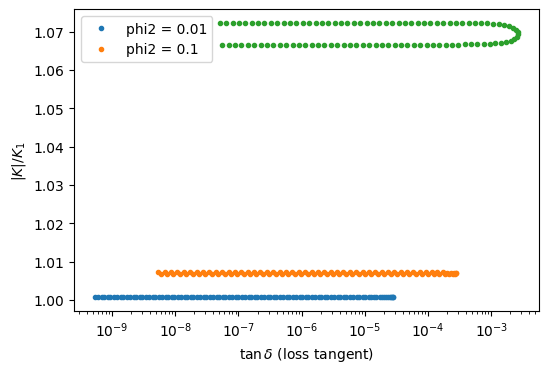

In [8]:
plt.figure(figsize=(6,4), dpi=100)

K_sweep = K_spher_incl2(K1, G1* mod2complex(De_vec), K2, 0.001)
plot_stiffness_loss(K_sweep, K1)

K_sweep = K_spher_incl2(K1, G1* mod2complex(De_vec), K2, 0.01)
plot_stiffness_loss(K_sweep, K1)

K_sweep = K_spher_incl2(K1, G1* mod2complex(De_vec), K2, 0.1)
plot_stiffness_loss(K_sweep, K1)

print(f"K1 = {K1:.2e}, K2 = {K2:.2e}")
plt.legend(["phi2 = 0.01", "phi2 = 0.1"])

Text(0.5, 1.0, 'phi2 = 0.1')

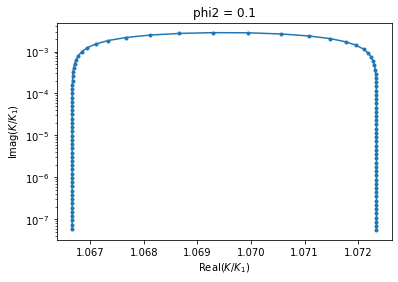

In [9]:
K_sweep = K_spher_incl2(K1, G1* mod2complex(De_vec), K2, 0.1)
# Curve fit explanatory data (N,)
x_data = De_vec
# Curve fit vector observations (N, 2)
y_data = np.stack((np.real(K_sweep)/K1, np.imag(K_sweep)/K1,), axis=-1)

plt.semilogy(y_data[:,0], y_data[:,1], '.-')
plt.xlabel("Real($K / K_1$)")
plt.ylabel("Imag($K / K_1$)")
plt.title("phi2 = 0.1")


In [10]:
''' Curve fit a generalized model: does it work?
Series spring-damper + spring-damper, plus parallel spring-damper.
This might be underfit!

Curve fit against real and complex components for each input Deborah number (frequency)
'''

def K_trial (De_vec, A, B, C, a, b, c):
  Kcomplex = 1 / (1/(A * mod2complex(a*De_vec) + B * mod2complex(b*De_vec)) + C/mod2complex(c*De_vec))
  return np.stack((np.real(Kcomplex), np.imag(Kcomplex),),axis=-1)

# Size adapter: first half of vector is the real part, second half is the imag part
_loader = lambda x, A, B, C, a, b, c : K_trial(x[:len(x)//2], A, B, C, a, b, c).ravel()

import scipy
import scipy.optimize
curve_out = scipy.optimize.curve_fit(_loader, np.concatenate((x_data, x_data,)), y_data.ravel(), full_output=True, maxfev=100000)

Comparing curve fit (dots) to complex K generated by sphere formula


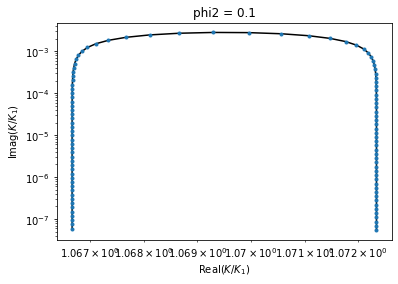

In [11]:
popt, pcov, infodict, mesg, ier = curve_out
K_fit = K_trial(De_vec, *popt)
plt.loglog(y_data[:,0], y_data[:,1], 'k-', label="Formula")
plt.loglog(K_fit[:,0], K_fit[:,1], '.', label="Standard model fit")

plt.xlabel("Real($K / K_1$)")
plt.ylabel("Imag($K / K_1$)")
plt.title("phi2 = 0.1")
print("Comparing curve fit (dots) to complex K generated by sphere formula")

In [12]:
''' SLS fit? Spring + damper in series, then adding a spring in parallel'''

def K_trial (De_vec, A, B):
  Kcomplex = A + B * mod2complex(De_vec)
  return np.stack((np.real(Kcomplex), np.imag(Kcomplex),),axis=-1)

y_data.ravel()
_loader = lambda x, A, B: K_trial(x[:len(x)//2], A, B).ravel()

import scipy
import scipy.optimize
curve_out = scipy.optimize.curve_fit(_loader, np.concatenate((x_data, x_data,)), y_data.ravel(), full_output=True, maxfev=100000)

In [13]:
popt, pcov, infodict, mesg, ier = curve_out
popt

array([1.06667751, 0.0056733 ])

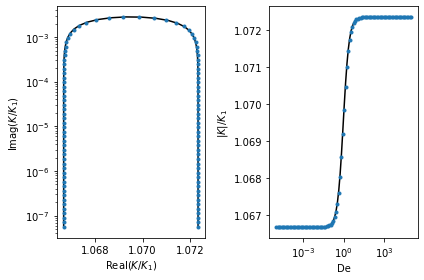

In [14]:
K_fit = K_trial(De_vec, *popt)
plt.subplot(1,2,1)
plt.semilogy(y_data[:,0], y_data[:,1], 'k-', label="Formula")
plt.semilogy(K_fit[:,0], K_fit[:,1], '.', label="Standard model fit")
plt.xlabel("Real($K / K_1$)")
plt.ylabel("Imag($K / K_1$)")

plt.subplot(1,2,2)
plt.semilogx(x_data, np.linalg.norm(y_data, axis=-1), 'k-', label="Formula")
plt.semilogx(x_data, np.linalg.norm(K_fit, axis=-1), '.', label="Standard model fit")
plt.xlabel("De")
plt.ylabel("$|K| / K_1$")
plt.tight_layout()

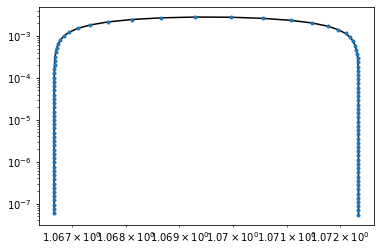

In [15]:
''' Propose SLS model equivalent
with algebraic form. Since the standard linear model has 3 degrees of freedom,
allowing one pole, one zero, and one prefactor, any transfer function from
strain to stress of the form

         (s - B)
H(s) = A -------
         (s - C)

can be identified with a standard linear model. The dilute spherical suspension
with a complex shear modulus G1 of the matrix is of this form.
'''

phi2 = 0.1
K1e = K1 * (1 + phi2 * (1 - K1/K2))
# alpha = 3 * (1 + phi2) * K1 * K2 - 3 * K1 * K1 * phi2
# beta = 4 * G1 * K1 * (1 - phi2) + 4 * G1 * K2 * phi2
# K2e = (alpha + beta) / (3 * K2 + 4 * G1) - K1e
K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)

# Bulk viscosity function, dependent on crust shear viscosity eta 
# For frequency domain, plug in Deborah number times 1j
# zetae = lambda eta: K2e * eta * (1 / G1 + 4/(3*K2))
zetae = lambda eta: 4/3 * eta * (1 - K1/K2)**2 * phi2

# Compute complex sweep of SLS equivalent
out = (K1e + zetae(De_vec*1j*G1/K2e) * (K1e + K2e)) / (1 + zetae(De_vec*1j*G1/K2e)) 
plt.loglog(y_data[:,0], y_data[:,1], 'k-', label="Formula")
plt.loglog(np.real(out) / K1, np.imag(out) / K1, '.')

In [16]:
# # Section for s-domain representation (not used in following code)
# alpha = 3*(1+phi2)*K1*K2-3*K1*K1*phi2
# beta = 4*G1*K1*(1-phi2)+4*G1*K2*phi2
# zeros = -G1/eta1*(3*(1+phi2)*K1*K2-3*K1*K1*phi2)/(3*(1+phi2)*K1*K2-3*K1*K1*phi2+4*G1*K1*(1-phi2)+4*G1*K2*phi2)
# poles = -1/((1/G1+4/(3*K2))*eta1)
# B = (3*(1+phi2)*K1*K2-3*K1*K1*phi2+4*G1*K1*(1-phi2)+4*G1*K2*phi2)/(3*K2 + 4 * G1)

In [17]:
def equiv_SLS(phi2, De_vec):
  ''' Equivalent standard linear solid, given a volume fraction.
  Returns a sweep of complex K(De), where De is the input vector of Deborah numbers.
  '''
  K1e = K1 * (1 + phi2 * (1 - K1/K2))
  K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
  # Bulk viscosity function, dependent on crust shear viscosity eta 
  # For frequency domain, plug in Deborah number times 1j
  zetae = lambda eta: 4/3 * eta * (1 - K1/K2)**2 * phi2
  # Compute complex sweep of SLS equivalent
  return (K1e + zetae(De_vec*1j*G1/K2e) * (K1e + K2e)) / (1 + zetae(De_vec*1j*G1/K2e)) 

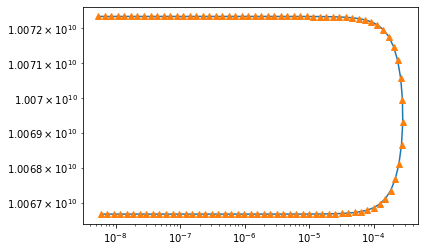

In [18]:
phi2 = 0.01

K_sweep = K_spher_incl2(K1, G1* mod2complex(De_vec), K2, phi2)
plt.loglog(np.imag(K_sweep) / np.real(K_sweep), np.abs(K_sweep), '-')

K_complex_SLS = equiv_SLS(phi2, De_vec)
plt.loglog(np.imag(K_complex_SLS) / np.real(K_complex_SLS), np.abs(K_complex_SLS), '^')


Shear modulus

In [19]:
def GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2):
  ''' Roots of the n = 3 generalized Maxwell model with transfer function
              s(s - z01)(s - z1)
  G(s) = A ------------------------
          (s - p0)(s - p1)(s - p2)
  for a dilute spherical inclusion (phase 2) in a viscoelastic matrix (phase 1)
  with bulk elastic properties and deviatoric viscosity
  '''
  roots_num = np.array([
    0,
    -((G1*((400*G1**2*G2**2*eta1**2*phi2**2 - 320*G1**2*G2**2*eta1**2*phi2 + 64*G1**2*G2**2*eta1**2 - 800*G1**2*G2**2*eta1*eta2*phi2**2 - 160*G1**2*G2**2*eta1*eta2*phi2 + 192*G1**2*G2**2*eta1*eta2 + 400*G1**2*G2**2*eta2**2*phi2**2 + 480*G1**2*G2**2*eta2**2*phi2 + 144*G1**2*G2**2*eta2**2 - 600*G1**2*G2*K1*eta1*eta2*phi2**2 + 600*G1**2*G2*K1*eta1*eta2*phi2 - 144*G1**2*G2*K1*eta1*eta2 + 600*G1**2*G2*K1*eta2**2*phi2**2 + 24*G1**2*G2*K1*eta2**2 + 225*G1**2*K1**2*eta2**2*phi2**2 - 270*G1**2*K1**2*eta2**2*phi2 + 81*G1**2*K1**2*eta2**2 + 600*G1*G2**2*K1*eta1**2*phi2**2 - 600*G1*G2**2*K1*eta1**2*phi2 + 144*G1*G2**2*K1*eta1**2 - 600*G1*G2**2*K1*eta1*eta2*phi2**2 - 24*G1*G2**2*K1*eta1*eta2 - 450*G1*G2*K1**2*eta1*eta2*phi2**2 + 540*G1*G2*K1**2*eta1*eta2*phi2 - 162*G1*G2*K1**2*eta1*eta2 + 225*G2**2*K1**2*eta1**2*phi2**2 - 270*G2**2*K1**2*eta1**2*phi2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2 - 15*G1*K1*eta2*phi2))/2 + (G1*(20*G1**2*phi2 - 8*G1**2 - 9*G1*K1 + 15*G1*K1*phi2)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)))/(eta1*eta2*(8*G1**2 - 20*G1**2*phi2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1 + 20*G1*G2*phi2 - 15*G1*K1*phi2 + 15*G2*K1*phi2)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*eta1*eta2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)),
    ((G1*((400*G1**2*G2**2*eta1**2*phi2**2 - 320*G1**2*G2**2*eta1**2*phi2 + 64*G1**2*G2**2*eta1**2 - 800*G1**2*G2**2*eta1*eta2*phi2**2 - 160*G1**2*G2**2*eta1*eta2*phi2 + 192*G1**2*G2**2*eta1*eta2 + 400*G1**2*G2**2*eta2**2*phi2**2 + 480*G1**2*G2**2*eta2**2*phi2 + 144*G1**2*G2**2*eta2**2 - 600*G1**2*G2*K1*eta1*eta2*phi2**2 + 600*G1**2*G2*K1*eta1*eta2*phi2 - 144*G1**2*G2*K1*eta1*eta2 + 600*G1**2*G2*K1*eta2**2*phi2**2 + 24*G1**2*G2*K1*eta2**2 + 225*G1**2*K1**2*eta2**2*phi2**2 - 270*G1**2*K1**2*eta2**2*phi2 + 81*G1**2*K1**2*eta2**2 + 600*G1*G2**2*K1*eta1**2*phi2**2 - 600*G1*G2**2*K1*eta1**2*phi2 + 144*G1*G2**2*K1*eta1**2 - 600*G1*G2**2*K1*eta1*eta2*phi2**2 - 24*G1*G2**2*K1*eta1*eta2 - 450*G1*G2*K1**2*eta1*eta2*phi2**2 + 540*G1*G2*K1**2*eta1*eta2*phi2 - 162*G1*G2*K1**2*eta1*eta2 + 225*G2**2*K1**2*eta1**2*phi2**2 - 270*G2**2*K1**2*eta1**2*phi2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2 + 15*G1*K1*eta2*phi2))/2 - (G1*(20*G1**2*phi2 - 8*G1**2 - 9*G1*K1 + 15*G1*K1*phi2)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)))/(eta1*eta2*(8*G1**2 - 20*G1**2*phi2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1 + 20*G1*G2*phi2 - 15*G1*K1*phi2 + 15*G2*K1*phi2)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*eta1*eta2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)),
  ])
  # Poles: independent of phi2
  roots_den = np.array([
    -G1/eta1,
    -((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2))/2 - (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
    ((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2))/2 + (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
  ]) 
  leading_coeff = ((G1*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2))/(6*(2*G1 + K1))
                   - (25*G1**2*phi2*(4*G1 + 3*K1)**2)/(6*(2*G1 + K1)*(G2*(12*G1 + 6*K1) + 8*G1**2 + 9*G1*K1)))
 
  return (roots_num, roots_den, leading_coeff)

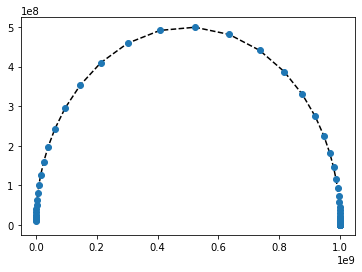

In [20]:
''' Verification at phi2 = 0 against pure phase complex shear modulus '''
eta1 = 1e12
eta2 = 1e6
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.0)

# Compute dimensional frequency sweep (1/s)
s_vec = (De_vec*1j)
# Complex composite shear modulus
G_s = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
plt.plot(np.real(G1_pure), np.imag(G1_pure), 'k--')
plt.plot(np.real(G_s), np.imag(G_s), 'o')


c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\937683530.py:19: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


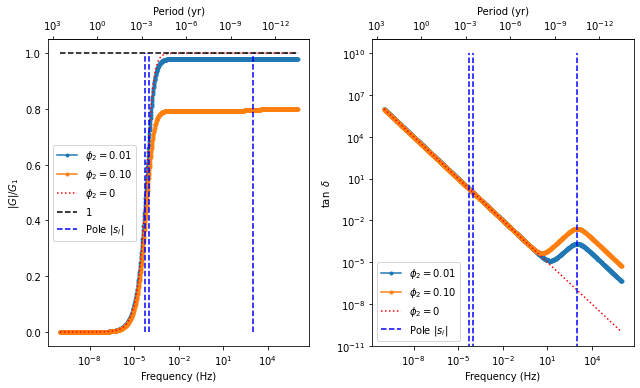

In [21]:
K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5
# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) *1j
# Compute pure 1-phase complex shear modulus
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(9,5.5))
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.subplot(1,2,1)
plt.semilogx(np.imag(s_vec), np.abs(G_s_001) / G1, '.-', label="$\phi_2 = 0.01$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_010) / G1, '.-', label="$\phi_2 = 0.10$")
plt.semilogx(np.imag(s_vec), np.abs(G1_pure) / G1, 'r:', label="$\phi_2 = 0$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k--', label="$1$")

plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel("$|G| / G_1$")
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)')

plt.subplot(1,2,2)
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '.-', label="$\phi_2 = 0.01$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '.-', label="$\phi_2 = 0.10$")
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r:', label="$\phi_2 = 0$")

plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tan~\delta$")
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)')

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

### Pres ready figures

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\3046952177.py:19: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


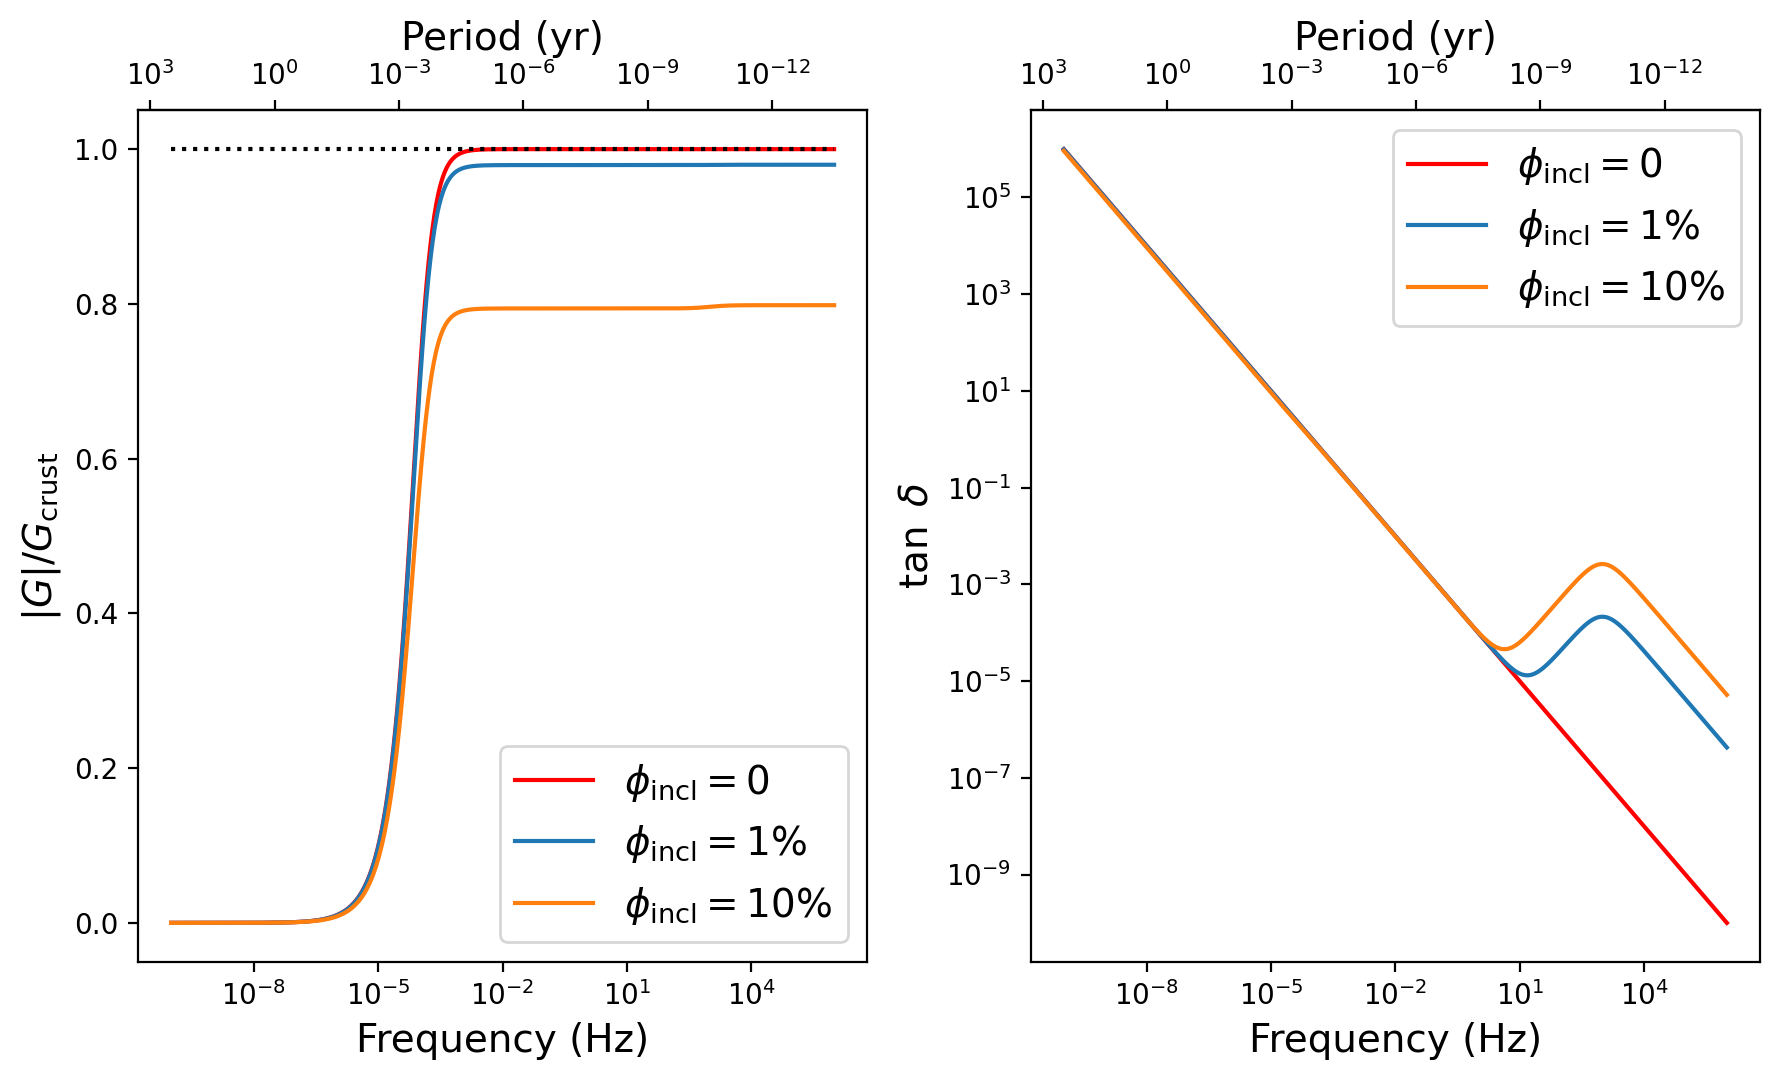

In [22]:
K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5
# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) *1j
# Compute pure 1-phase complex shear modulus
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(9,5.5), dpi=200)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.subplot(1,2,1)
plt.semilogx(np.imag(s_vec), np.abs(G1_pure) / G1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_001) / G1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_010) / G1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|G| / G_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.subplot(1,2,2)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\466235926.py:19: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


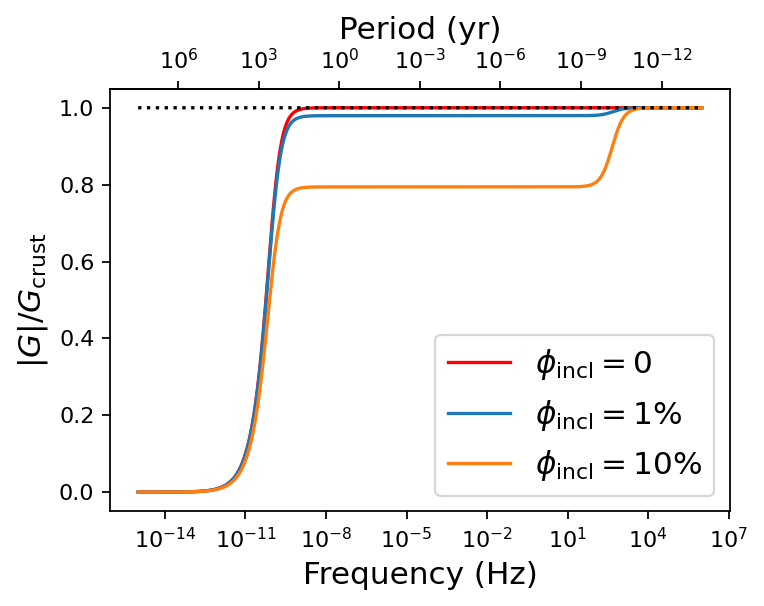

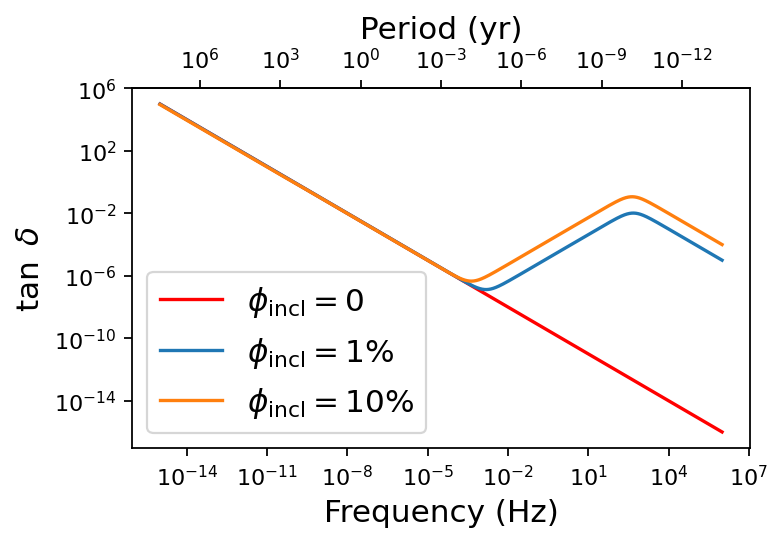

In [23]:
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta1 = 1e20
eta2 = 1e7
# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-15, 1e6, 3000) *1j
# Compute pure 1-phase complex shear modulus
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(5,3.5), dpi=160)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.semilogx(np.imag(s_vec), np.abs(G1_pure) / G1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_001) / G1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_010) / G1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|G| / G_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.figure(figsize=(5,3.5), dpi=160)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

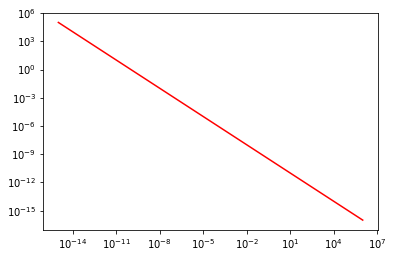

In [24]:
plt.plot()
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")


In [25]:
import matplotlib
matplotlib.ticker.FuncFormatter


matplotlib.ticker.FuncFormatter

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\2390412926.py:20: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


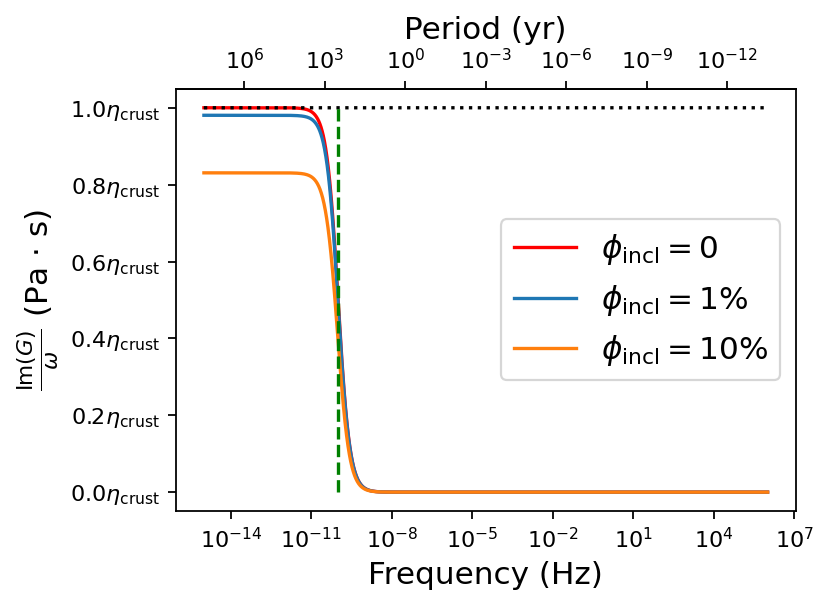

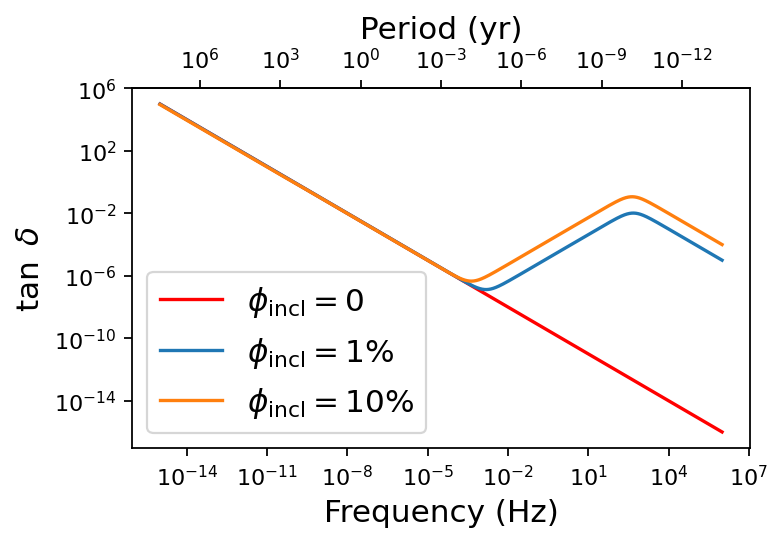

In [26]:
# DUPLICATe
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta1 = 1e20
eta2 = 1e7
# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-15, 1e6, 3000) *1j
# Compute pure 1-phase complex shear modulus
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(5,3.5), dpi=160)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.semilogx(np.imag(s_vec), np.imag(G1_pure) / np.imag(s_vec) / eta1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.imag(G_s_001) / np.imag(s_vec) / eta1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.imag(G_s_010) / np.imag(s_vec) / eta1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

plt.semilogx((G1/ eta1) * np.array([1, 1]),  np.array([0, 1]), 'g--')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
  lambda x, pos: f"${x:.1f} \eta_\mathrm{{crust}}$"
))



plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\frac{\mathrm{Im}(G)}{\omega}$ (Pa $\cdot$ s)", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.figure(figsize=(5,3.5), dpi=160)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

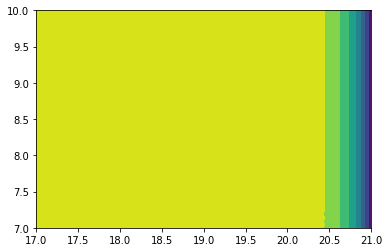

In [27]:
# Low-frequency limit of shear modulus
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta1 = 1e20
eta2 = 1e7

eta1_range = np.geomspace(1e17, 1e21, 60)
eta2_range = np.geomspace(1e7, 1e10, 70)

mg_eta1, mg_eta2 = np.meshgrid(eta1_range, eta2_range)
mg_effective_G_001 = np.full_like(mg_eta1, -1.0)
mg_effective_G_010 = np.full_like(mg_eta1, -1.0)

for j, eta1 in enumerate(eta1_range):
  for i, eta2 in enumerate(eta2_range):
    # Scalar value of low-frequency "limit"
    s_eps = 1e-11
    s_vec = np.array([s_eps]) *1j
    # Compute pure 1-phase complex shear modulus
    G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
    # Compute composite complex shear modulus
    roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.01)
    G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
    roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, 0.10)
    G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

    mg_effective_G_001[i,j] = np.abs(np.imag(G_s_001 / eta1 / s_eps))
    mg_effective_G_010[i,j] = np.abs(np.imag(G_s_010 / eta1 / s_eps))

plt.contourf(np.log10(mg_eta1), np.log10(mg_eta2), np.log10(mg_effective_G_001))


In [28]:

roots_num, roots_den, leading_coeff = GMM_poly_roots(K1, K2, G1, G2, 1e23, eta2, 0.01)
s_vec[:] = 1e-13j
leading_coeff * (np.polynomial.Polynomial.fromroots(roots_num)(s_vec)
                 / np.polynomial.Polynomial.fromroots(roots_den)(s_vec)), \
        leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

(array([4.90680075e+09+4.89406268e+09j]),
 array([4.90680075e+09+4.89406268e+09j]))

In [29]:
scal = 1e18
roots_num, roots_den, leading_coeff = GMM_poly_roots(K1/scal, K2/scal, G1/scal, G2/scal, 1e21/scal, eta2/scal, 0.01)
roots_num, roots_den, leading_coeff

scal * leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

array([990612.10523743+98322402.5615257j])

In [30]:
(s_vec - roots_num[:, np.newaxis])

array([[0.00000000e+00+1.e-13j],
       [4.75714286e-01+1.e-13j],
       [5.31524824e-12+1.e-13j]])

In [31]:
(s_vec - roots_num[:]).prod(axis=0) / (s_vec - roots_num[:-1]).prod(axis=0)

(5.315248241544168e-12+1e-13j)

In [32]:
roots_den
np.polynomial.polynomial.polyfromroots(roots_num)


array([0.00000000e+00, 2.52853952e-12, 4.75714286e-01, 1.00000000e+00])

In [33]:
(s_vec - roots_den[:, np.newaxis]).prod()

(2.570933553728326e-23+7.428562125251194e-25j)

In [34]:

def GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2):
  ''' Roots of the n = 3 generalized Maxwell model with transfer function
              s(s - z01)(s - z1)
  G(s) = A ------------------------
          (s - p0)(s - p1)(s - p2)
  for a dilute spherical inclusion (phase 2) in a viscoelastic matrix (phase 1)
  with bulk elastic properties and deviatoric viscosity
  '''
  roots_num = np.array([
    0,
    -((G1*((400*G1**2*G2**2*eta1**2*phi2**2 - 320*G1**2*G2**2*eta1**2*phi2 + 64*G1**2*G2**2*eta1**2 - 800*G1**2*G2**2*eta1*eta2*phi2**2 - 160*G1**2*G2**2*eta1*eta2*phi2 + 192*G1**2*G2**2*eta1*eta2 + 400*G1**2*G2**2*eta2**2*phi2**2 + 480*G1**2*G2**2*eta2**2*phi2 + 144*G1**2*G2**2*eta2**2 - 600*G1**2*G2*K1*eta1*eta2*phi2**2 + 600*G1**2*G2*K1*eta1*eta2*phi2 - 144*G1**2*G2*K1*eta1*eta2 + 600*G1**2*G2*K1*eta2**2*phi2**2 + 24*G1**2*G2*K1*eta2**2 + 225*G1**2*K1**2*eta2**2*phi2**2 - 270*G1**2*K1**2*eta2**2*phi2 + 81*G1**2*K1**2*eta2**2 + 600*G1*G2**2*K1*eta1**2*phi2**2 - 600*G1*G2**2*K1*eta1**2*phi2 + 144*G1*G2**2*K1*eta1**2 - 600*G1*G2**2*K1*eta1*eta2*phi2**2 - 24*G1*G2**2*K1*eta1*eta2 - 450*G1*G2*K1**2*eta1*eta2*phi2**2 + 540*G1*G2*K1**2*eta1*eta2*phi2 - 162*G1*G2*K1**2*eta1*eta2 + 225*G2**2*K1**2*eta1**2*phi2**2 - 270*G2**2*K1**2*eta1**2*phi2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2 - 15*G1*K1*eta2*phi2))/2 + (G1*(20*G1**2*phi2 - 8*G1**2 - 9*G1*K1 + 15*G1*K1*phi2)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)))/(eta1*eta2*(8*G1**2 - 20*G1**2*phi2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1 + 20*G1*G2*phi2 - 15*G1*K1*phi2 + 15*G2*K1*phi2)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*eta1*eta2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)),
    ((G1*((400*G1**2*G2**2*eta1**2*phi2**2 - 320*G1**2*G2**2*eta1**2*phi2 + 64*G1**2*G2**2*eta1**2 - 800*G1**2*G2**2*eta1*eta2*phi2**2 - 160*G1**2*G2**2*eta1*eta2*phi2 + 192*G1**2*G2**2*eta1*eta2 + 400*G1**2*G2**2*eta2**2*phi2**2 + 480*G1**2*G2**2*eta2**2*phi2 + 144*G1**2*G2**2*eta2**2 - 600*G1**2*G2*K1*eta1*eta2*phi2**2 + 600*G1**2*G2*K1*eta1*eta2*phi2 - 144*G1**2*G2*K1*eta1*eta2 + 600*G1**2*G2*K1*eta2**2*phi2**2 + 24*G1**2*G2*K1*eta2**2 + 225*G1**2*K1**2*eta2**2*phi2**2 - 270*G1**2*K1**2*eta2**2*phi2 + 81*G1**2*K1**2*eta2**2 + 600*G1*G2**2*K1*eta1**2*phi2**2 - 600*G1*G2**2*K1*eta1**2*phi2 + 144*G1*G2**2*K1*eta1**2 - 600*G1*G2**2*K1*eta1*eta2*phi2**2 - 24*G1*G2**2*K1*eta1*eta2 - 450*G1*G2*K1**2*eta1*eta2*phi2**2 + 540*G1*G2*K1**2*eta1*eta2*phi2 - 162*G1*G2*K1**2*eta1*eta2 + 225*G2**2*K1**2*eta1**2*phi2**2 - 270*G2**2*K1**2*eta1**2*phi2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2 + 15*G1*K1*eta2*phi2))/2 - (G1*(20*G1**2*phi2 - 8*G1**2 - 9*G1*K1 + 15*G1*K1*phi2)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)))/(eta1*eta2*(8*G1**2 - 20*G1**2*phi2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1 + 20*G1*G2*phi2 - 15*G1*K1*phi2 + 15*G2*K1*phi2)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*eta1*eta2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)),
  ])
  # Poles: independent of phi2
  roots_den = np.array([
    -G1/eta1,
    -((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2))/2 - (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
    ((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2))/2 + (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
  ]) 
  leading_coeff = ((G1*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2))/(6*(2*G1 + K1))
                   - (25*G1**2*phi2*(4*G1 + 3*K1)**2)/(6*(2*G1 + K1)*(G2*(12*G1 + 6*K1) + 8*G1**2 + 9*G1*K1)))
 
  return (roots_num, roots_den, leading_coeff)

In [35]:
GMM_poly_roots(K1/scal, K2/scal, G1/scal, G2/scal, eta1/scal, eta2/scal, 0.01)[1].dtype

K1_2 = K1
np.array([np.longdouble(K1_2)]).dtype

dtype('float64')

Text(0, 0.5, '$\\frac{\\mathrm{Im}(G)}{\\omega}$ (Pa $\\cdot$ s)')

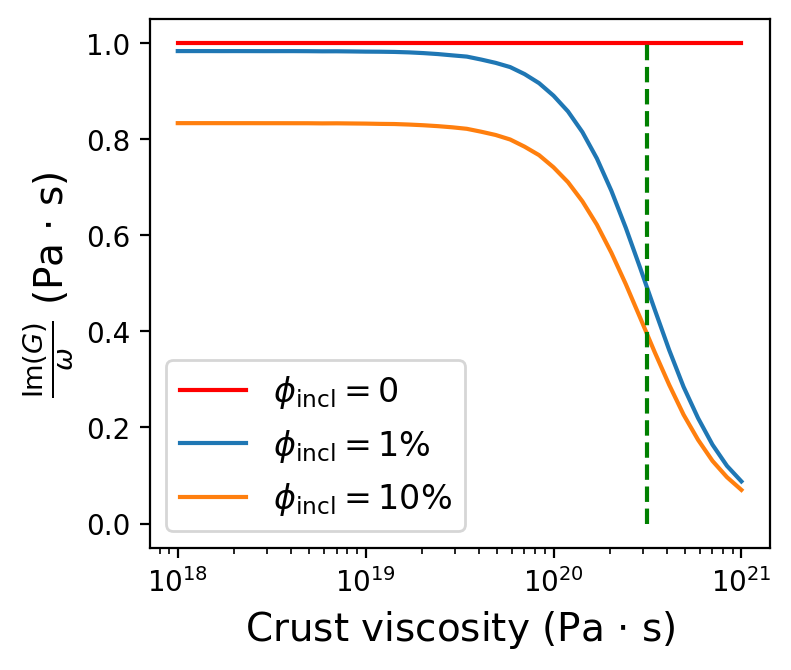

In [37]:
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta2 = 1e7

eta1_range = np.geomspace(1e18, 1e21, 40)
vec_effective_G_001 = np.full_like(eta1_range, -1.0)
vec_deltad_001 = np.full_like(eta1_range, -1.0)
vec_effective_G_010 = np.full_like(eta1_range, -1.0)
vec_deltad_010 = np.full_like(eta1_range, -1.0)

s_eps = 1 / (1000 * 3.1536e+7)
s_vec = np.array([s_eps]) *1j
# Scaling constant
scal = 1

for j, eta1 in enumerate(eta1_range):
  # Scalar value of low-frequency "limit"
  # Compute pure 1-phase complex shear modulus
  G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
  # Compute composite complex shear modulus
  roots_num, roots_den, leading_coeff = GMM_poly_roots(K1/scal, K2/scal, G1/scal, G2/scal, eta1/scal, eta2/scal, 0.01)
  G_s_001 = scal * leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
  roots_num, roots_den, leading_coeff = GMM_poly_roots(K1/scal, K2/scal, G1/scal, G2/scal, eta1/scal, eta2/scal, 0.10)
  G_s_010 = scal * leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

  vec_effective_G_001[j] = np.imag(G_s_001 / eta1 / s_eps)
  vec_deltad_001[j] = np.imag(G_s_001) / np.real(G_s_001)

  vec_effective_G_010[j] = np.imag(G_s_010 / eta1 / s_eps)
  vec_deltad_010[j] = np.imag(G_s_010) / np.real(G_s_010)

plt.figure(figsize=(4,3.5), dpi=200)
plt.semilogx(eta1_range, np.ones_like(eta1_range), 'r', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(eta1_range, vec_effective_G_001, label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(eta1_range, vec_effective_G_010, label="$\phi_\mathrm{incl} = 10\%$")

plt.semilogx((G1 / s_eps) * np.array([1, 1]),  np.array([0, 1]), 'g--')#, label="$1$")


plt.legend(fontsize=12)
plt.xlabel(f"Crust viscosity (Pa $\cdot$ s)", fontsize=14)
plt.ylabel(r"$\frac{\mathrm{Im}(G)}{\omega}$ (Pa $\cdot$ s)", fontsize=14)

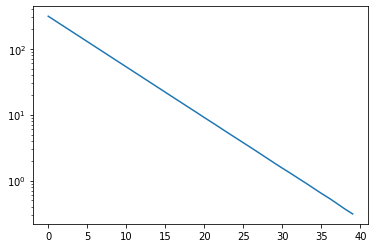

In [38]:
plt.semilogy(vec_deltad_001)

Poles

Plot of poles for complex shear modulus. Black line: pure crust relaxation rate


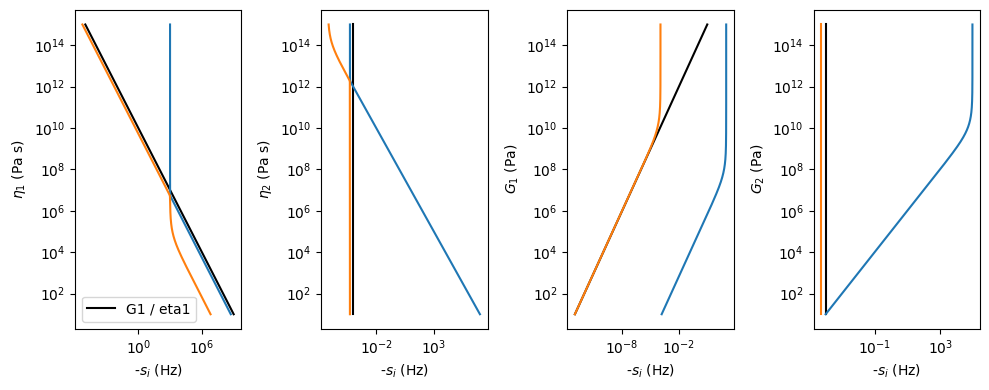

In [39]:
plt.figure(figsize=(10,4), dpi=100)

plt.subplot(1,4,1)
K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5
eta1_sweep = np.geomspace(1e1, 1e15, 1000)
phi2 = 0.1
poles = np.empty((eta1_sweep.size, 3))
for i, eta1 in enumerate(eta1_sweep):
  _, poles[i,:], _ = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2)
plt.loglog(-poles[:,0], eta1_sweep, 'k-', label="G1 / eta1")
plt.loglog(-poles[:,1:], eta1_sweep, '-')
plt.xlabel("-$s_i$ (Hz)")
plt.ylabel("$\eta_1$ (Pa s)")
plt.legend()

plt.subplot(1,4,2)
K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5
eta2_sweep = np.geomspace(1e1, 1e15, 1000)
phi2 = 0.1
poles = np.empty((eta2_sweep.size, 3))
for i, eta2 in enumerate(eta2_sweep):
  _, poles[i,:], _ = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2)
plt.loglog(-poles[:,0], eta2_sweep, 'k-', label="G1 / eta1")
plt.loglog(-poles[:,1:], eta2_sweep, '-')
plt.xlabel("-$s_i$ (Hz)")
plt.ylabel("$\eta_2$ (Pa s)")

plt.subplot(1,4,3)
K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5
G1_sweep = np.geomspace(1e1, 1e15, 1000)
phi2 = 0.1
poles = np.empty((G1_sweep.size, 3))
for i, G1 in enumerate(G1_sweep):
  _, poles[i,:], _ = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2)
plt.loglog(-poles[:,0], G1_sweep, 'k-', label="G1 / eta1")
plt.loglog(-poles[:,1:], G1_sweep, '-')
plt.xlabel("-$s_i$ (Hz)")
plt.ylabel("$G_1$ (Pa)")

plt.subplot(1,4,4)
K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5
G2_sweep = np.geomspace(1e1, 1e15, 1000)
phi2 = 0.1
poles = np.empty((G2_sweep.size, 3))
for i, G2 in enumerate(G2_sweep):
  _, poles[i,:], _ = GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2)
plt.loglog(-poles[:,0], G2_sweep, 'k-', label="G1 / eta1")
plt.loglog(-poles[:,1:], G2_sweep, '-')
plt.xlabel("-$s_i$ (Hz)")
plt.ylabel("$G_2$ (Pa)")

plt.tight_layout()

print("Plot of poles for complex shear modulus. Black line: pure crust relaxation rate")

In [40]:
roots_num, roots_den

(array([ 0.00000000e+00, -3.85714286e+02, -5.45696821e-12]),
 array([-1.00000000e-11, -4.85714286e+02, -5.17275112e-12]))

In [41]:
# Prony series approximation at low frequency

In [42]:

s_vec = np.geomspace(1e-10, 1e6, 1000) *1j

K_s_001 = equiv_SLS(phi2, s_vec)

In [43]:
( np.abs(K_s_001) / K1).shape

(1000,)

C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\3909559903.py:30: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


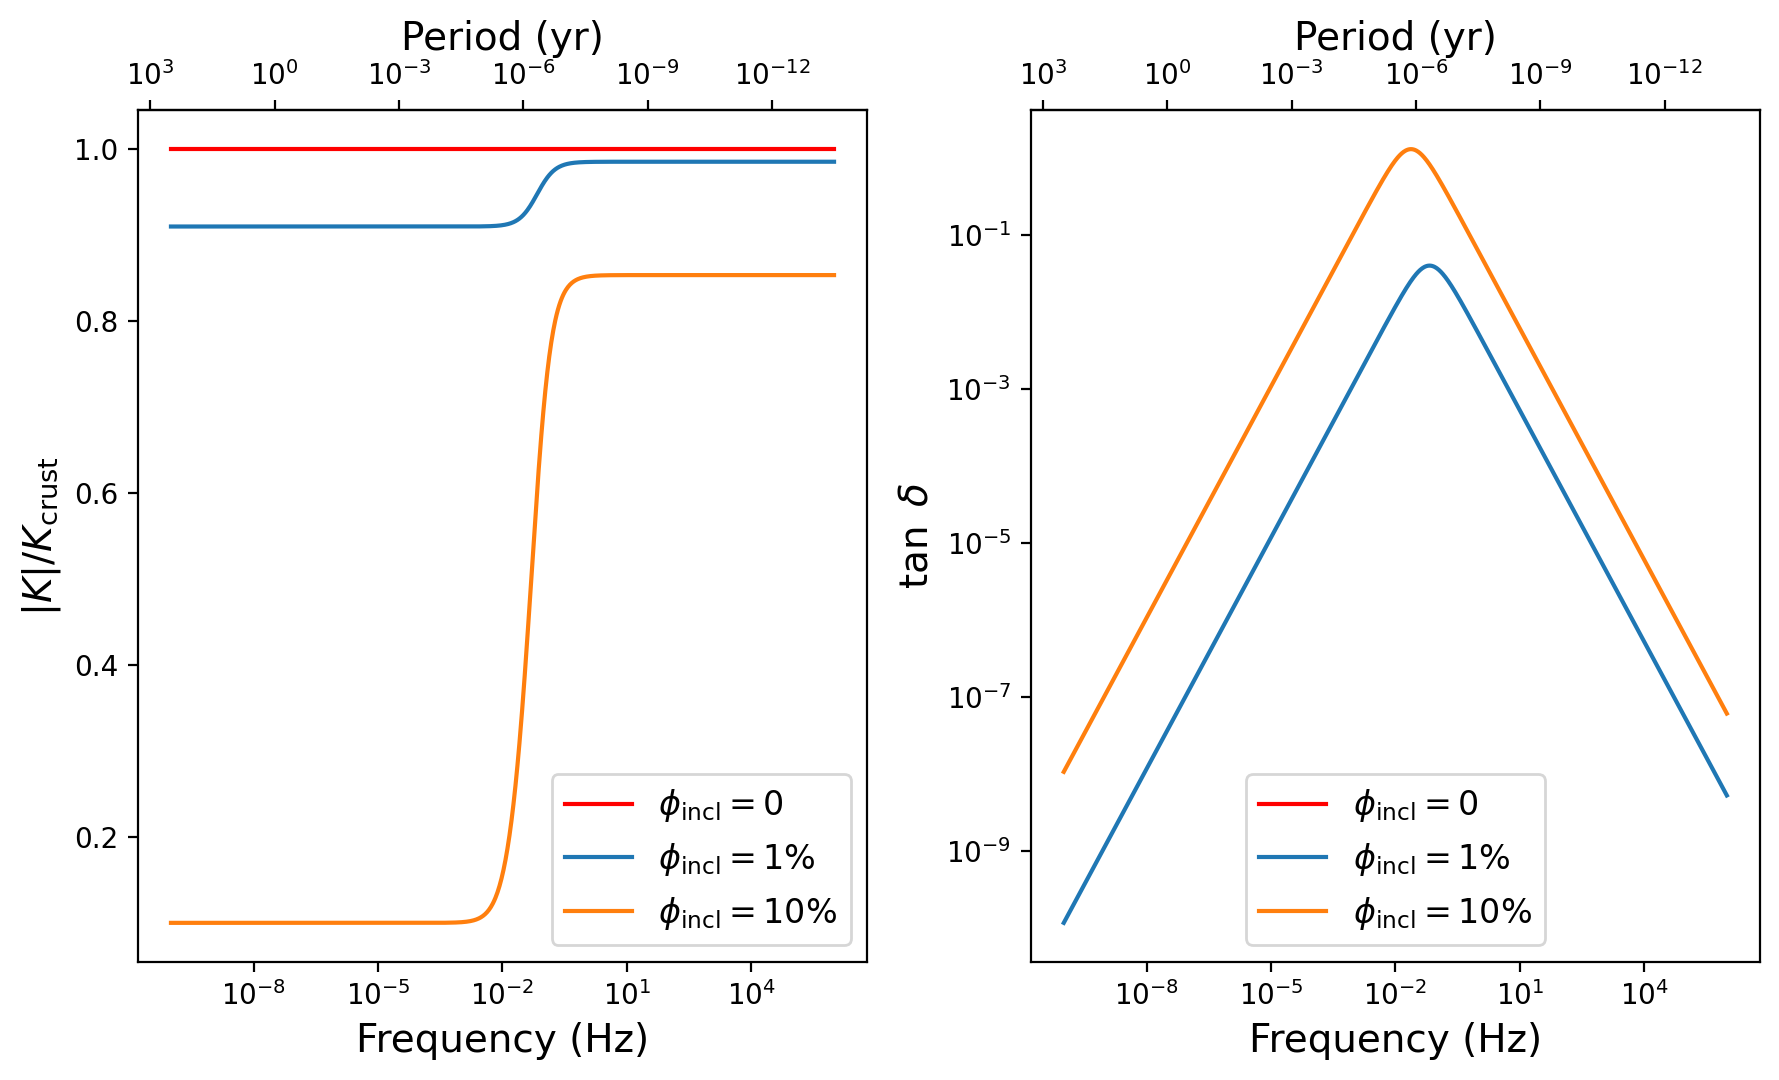

In [44]:

K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5

def equiv_SLS(phi2, De_vec):
  ''' Equivalent standard linear solid, given a volume fraction.
  Returns a sweep of complex K(De), where De is the input vector of Deborah numbers.
  '''
  K1e = K1 * (1 + phi2 * (1 - K1/K2))
  K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
  # Bulk viscosity function, dependent on crust shear viscosity eta 
  # For frequency domain, plug in Deborah number times 1j
  zetae = lambda eta: 4/3 * eta * (1 - K1/K2)**2 * phi2
  # Compute complex sweep of SLS equivalent
  return (K1e + zetae(De_vec*1j*G1/K2e) * (K1e + K2e)) / (1 + zetae(De_vec*1j*G1/K2e))

# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) * 1
# Compute pure 1-phase complex shear modulus
K1_pure = K1
# Compute composite complex shear modulus
K_s_001 = equiv_SLS(0.01, s_vec)
K_s_010 = equiv_SLS(0.1, s_vec)

plt.figure(figsize=(9,5.5), dpi=200)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.subplot(1,2,1)
plt.semilogx(np.real(s_vec), np.ones_like(s_vec, dtype=float), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.real(s_vec), np.abs(K_s_001) / K1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.real(s_vec), np.abs(K_s_010) / K1, '-', label="$\phi_\mathrm{incl} = 10\%$")
# plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend(fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|K| / K_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.subplot(1,2,2)
plt.loglog(np.real(s_vec), 0 * s_vec, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.real(s_vec), np.imag(K_s_001) / np.real(K_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.real(s_vec), np.imag(K_s_010) / np.real(K_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)


plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\454406364.py:38: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


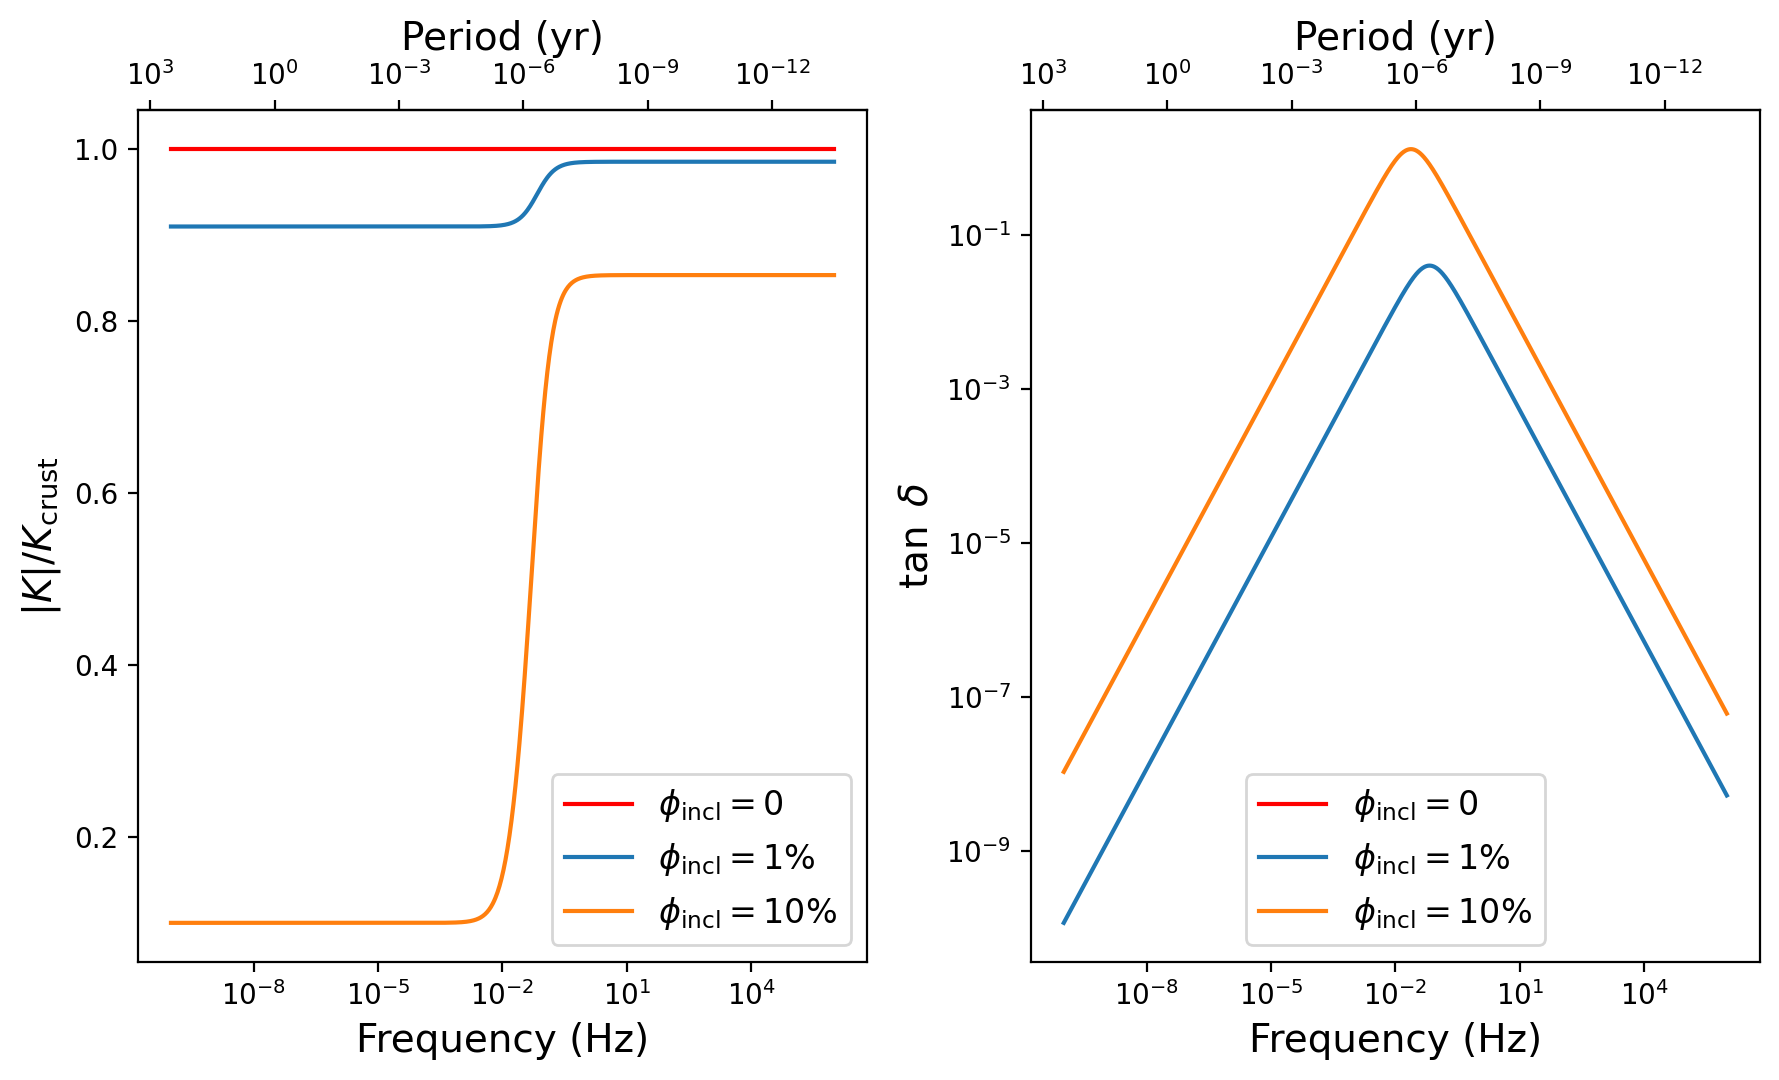

In [45]:
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta1 = 1e20
eta2 = 1e7


K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5

def equiv_SLS(phi2, De_vec):
  ''' Equivalent standard linear solid, given a volume fraction.
  Returns a sweep of complex K(De), where De is the input vector of Deborah numbers.
  '''
  K1e = K1 * (1 + phi2 * (1 - K1/K2))
  K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
  # Bulk viscosity function, dependent on crust shear viscosity eta 
  # For frequency domain, plug in Deborah number times 1j
  zetae = lambda eta: 4/3 * eta * (1 - K1/K2)**2 * phi2
  # Compute complex sweep of SLS equivalent
  return (K1e + zetae(De_vec*1j*G1/K2e) * (K1e + K2e)) / (1 + zetae(De_vec*1j*G1/K2e))

# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) * 1
# Compute pure 1-phase complex shear modulus
K1_pure = K1
# Compute composite complex shear modulus
K_s_001 = equiv_SLS(0.01, s_vec)
K_s_010 = equiv_SLS(0.1, s_vec)

plt.figure(figsize=(9,5.5), dpi=200)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.subplot(1,2,1)
plt.semilogx(np.real(s_vec), np.ones_like(s_vec, dtype=float), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.real(s_vec), np.abs(K_s_001) / K1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.real(s_vec), np.abs(K_s_010) / K1, '-', label="$\phi_\mathrm{incl} = 10\%$")
# plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend(fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|K| / K_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.subplot(1,2,2)
plt.loglog(np.real(s_vec), 0 * s_vec, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.real(s_vec), np.imag(K_s_001) / np.real(K_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.real(s_vec), np.imag(K_s_010) / np.real(K_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)


plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

Variant with vertical dashed line

C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\3659744947.py:30: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


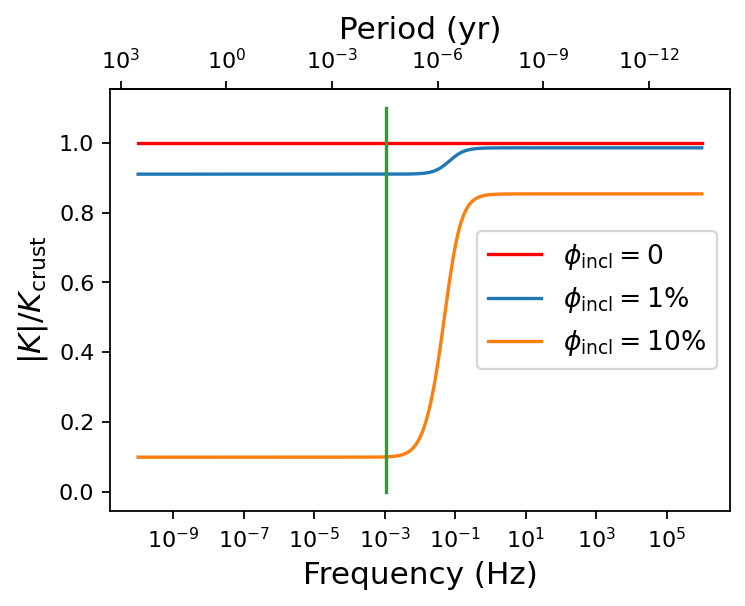

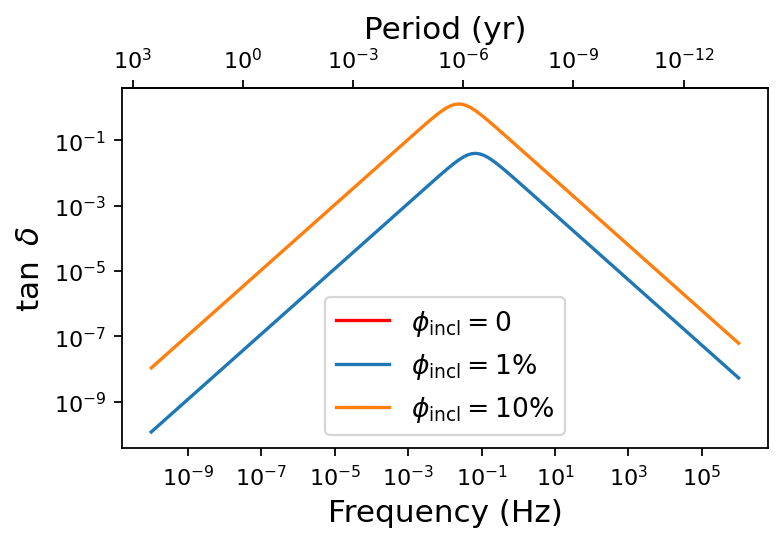

In [46]:

K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5

def equiv_SLS(phi2, De_vec):
  ''' Equivalent standard linear solid, given a volume fraction.
  Returns a sweep of complex K(De), where De is the input vector of Deborah numbers.
  '''
  K1e = K1 * (1 + phi2 * (1 - K1/K2))
  K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
  # Bulk viscosity function, dependent on crust shear viscosity eta 
  # For frequency domain, plug in Deborah number times 1j
  zetae = lambda eta: 4/3 * eta * (1 - K1/K2)**2 * phi2
  # Compute complex sweep of SLS equivalent
  return (K1e + zetae(De_vec*1j*G1/K2e) * (K1e + K2e)) / (1 + zetae(De_vec*1j*G1/K2e))

# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) * 1
# Compute pure 1-phase complex shear modulus
K1_pure = K1
# Compute composite complex shear modulus
K_s_001 = equiv_SLS(0.01, s_vec)
K_s_010 = equiv_SLS(0.1, s_vec)

plt.figure(figsize=(5,3.5), dpi=160)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.semilogx(np.real(s_vec), np.ones_like(s_vec, dtype=float), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.real(s_vec), np.abs(K_s_001) / K1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.real(s_vec), np.abs(K_s_010) / K1, '-', label="$\phi_\mathrm{incl} = 10\%$")
# plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend(fontsize=12, loc="right")
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|K| / K_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

# Vertical dashed line
phi2 = 0.1
K1e = K1 * (1 + phi2 * (1 - K1/K2))
K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
# Bulk viscosity function, dependent on crust shear viscosity eta 
# For frequency domain, plug in Deborah number times 1j
zetae = 4/3 * eta2 * (1 - K1/K2)**2 * phi2

plt.plot(np.array([1, 1]) * zetae/K1e, np.array([0, 1.1]))

plt.figure(figsize=(5,3.5), dpi=160)
plt.loglog(np.real(s_vec), 0 * s_vec, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.real(s_vec), np.imag(K_s_001) / np.real(K_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.real(s_vec), np.imag(K_s_010) / np.real(K_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

C:\Users\Fredric\AppData\Local\Temp\ipykernel_44888\3659744947.py:30: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


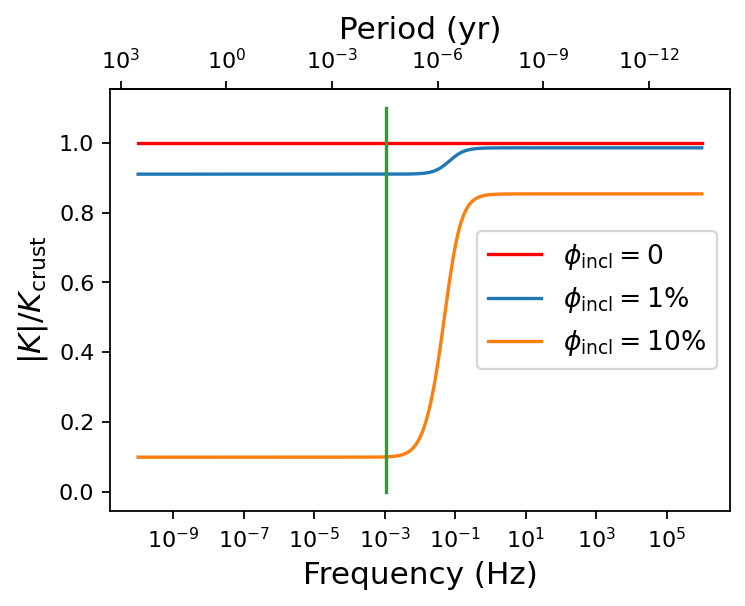

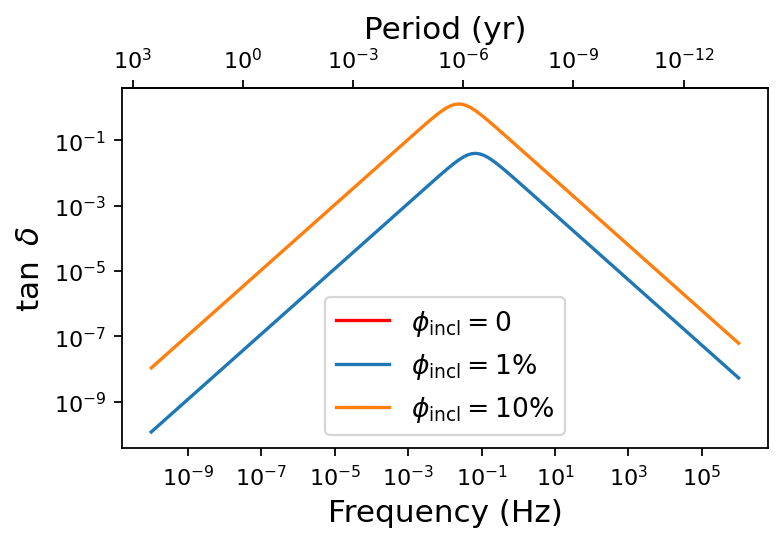

In [47]:

K1 = 10e9
K2 = 1e9
G1 = 10e9
G2 = 1e8
eta1 = 1e14
eta2 = 1e5

def equiv_SLS(phi2, De_vec):
  ''' Equivalent standard linear solid, given a volume fraction.
  Returns a sweep of complex K(De), where De is the input vector of Deborah numbers.
  '''
  K1e = K1 * (1 + phi2 * (1 - K1/K2))
  K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
  # Bulk viscosity function, dependent on crust shear viscosity eta 
  # For frequency domain, plug in Deborah number times 1j
  zetae = lambda eta: 4/3 * eta * (1 - K1/K2)**2 * phi2
  # Compute complex sweep of SLS equivalent
  return (K1e + zetae(De_vec*1j*G1/K2e) * (K1e + K2e)) / (1 + zetae(De_vec*1j*G1/K2e))

# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) * 1
# Compute pure 1-phase complex shear modulus
K1_pure = K1
# Compute composite complex shear modulus
K_s_001 = equiv_SLS(0.01, s_vec)
K_s_010 = equiv_SLS(0.1, s_vec)

plt.figure(figsize=(5,3.5), dpi=160)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.semilogx(np.real(s_vec), np.ones_like(s_vec, dtype=float), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.real(s_vec), np.abs(K_s_001) / K1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.real(s_vec), np.abs(K_s_010) / K1, '-', label="$\phi_\mathrm{incl} = 10\%$")
# plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1]), 'b--')

plt.legend(fontsize=12, loc="right")
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|K| / K_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

# Vertical dashed line
phi2 = 0.1
K1e = K1 * (1 + phi2 * (1 - K1/K2))
K2e = (K2 - K1)*(K2 - K1) / K2 * phi2 * 4 * G1 / (3 * K2 + 4  * G1)
# Bulk viscosity function, dependent on crust shear viscosity eta 
# For frequency domain, plug in Deborah number times 1j
zetae = 4/3 * eta2 * (1 - K1/K2)**2 * phi2

plt.plot(np.array([1, 1]) * zetae/K1e, np.array([0, 1.1]))

plt.figure(figsize=(5,3.5), dpi=160)
plt.loglog(np.real(s_vec), 0 * s_vec, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.real(s_vec), np.imag(K_s_001) / np.real(K_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.real(s_vec), np.imag(K_s_010) / np.real(K_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

# plt.plot(np.abs(roots_den[0]) * np.array([1, 1]), np.array([0, 1e10]), 'b--', label="Pole $|s_i|$")
# plt.plot(np.abs(roots_den[1]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')
# plt.plot(np.abs(roots_den[2]) * np.array([1, 1]), np.array([0, 1e10]), 'b--')

plt.legend(fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

In [48]:
zetae / K1e

0.00108

In [50]:
# np.abs(K_s_001)

C:\Users\Fredric\AppData\Roaming\Python\Python39\site-packages\matplotlib_inline\backend_inline.py:234: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  for label in axis.get_ticklabels()])


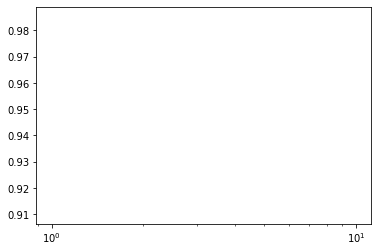

In [51]:
plt.semilogx(np.imag(s_vec), np.real(K_s_001) / K1)

End-member cases

In [52]:
def GMM_poly_roots(K1, K2, G1, G2, eta1, eta2, phi2):
  ''' Roots of the n = 3 generalized Maxwell model with transfer function
              s(s - z01)(s - z1)
  G(s) = A ------------------------
          (s - p0)(s - p1)(s - p2)
  for a dilute spherical inclusion (phase 2) in a viscoelastic matrix (phase 1)
  with bulk elastic properties and deviatoric viscosity
  '''
  roots_num = np.array([
    0,
    -((G1*((400*G1**2*G2**2*eta1**2*phi2**2 - 320*G1**2*G2**2*eta1**2*phi2 + 64*G1**2*G2**2*eta1**2 - 800*G1**2*G2**2*eta1*eta2*phi2**2 - 160*G1**2*G2**2*eta1*eta2*phi2 + 192*G1**2*G2**2*eta1*eta2 + 400*G1**2*G2**2*eta2**2*phi2**2 + 480*G1**2*G2**2*eta2**2*phi2 + 144*G1**2*G2**2*eta2**2 - 600*G1**2*G2*K1*eta1*eta2*phi2**2 + 600*G1**2*G2*K1*eta1*eta2*phi2 - 144*G1**2*G2*K1*eta1*eta2 + 600*G1**2*G2*K1*eta2**2*phi2**2 + 24*G1**2*G2*K1*eta2**2 + 225*G1**2*K1**2*eta2**2*phi2**2 - 270*G1**2*K1**2*eta2**2*phi2 + 81*G1**2*K1**2*eta2**2 + 600*G1*G2**2*K1*eta1**2*phi2**2 - 600*G1*G2**2*K1*eta1**2*phi2 + 144*G1*G2**2*K1*eta1**2 - 600*G1*G2**2*K1*eta1*eta2*phi2**2 - 24*G1*G2**2*K1*eta1*eta2 - 450*G1*G2*K1**2*eta1*eta2*phi2**2 + 540*G1*G2*K1**2*eta1*eta2*phi2 - 162*G1*G2*K1**2*eta1*eta2 + 225*G2**2*K1**2*eta1**2*phi2**2 - 270*G2**2*K1**2*eta1**2*phi2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2 - 15*G1*K1*eta2*phi2))/2 + (G1*(20*G1**2*phi2 - 8*G1**2 - 9*G1*K1 + 15*G1*K1*phi2)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)))/(eta1*eta2*(8*G1**2 - 20*G1**2*phi2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1 + 20*G1*G2*phi2 - 15*G1*K1*phi2 + 15*G2*K1*phi2)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*eta1*eta2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)),
    ((G1*((400*G1**2*G2**2*eta1**2*phi2**2 - 320*G1**2*G2**2*eta1**2*phi2 + 64*G1**2*G2**2*eta1**2 - 800*G1**2*G2**2*eta1*eta2*phi2**2 - 160*G1**2*G2**2*eta1*eta2*phi2 + 192*G1**2*G2**2*eta1*eta2 + 400*G1**2*G2**2*eta2**2*phi2**2 + 480*G1**2*G2**2*eta2**2*phi2 + 144*G1**2*G2**2*eta2**2 - 600*G1**2*G2*K1*eta1*eta2*phi2**2 + 600*G1**2*G2*K1*eta1*eta2*phi2 - 144*G1**2*G2*K1*eta1*eta2 + 600*G1**2*G2*K1*eta2**2*phi2**2 + 24*G1**2*G2*K1*eta2**2 + 225*G1**2*K1**2*eta2**2*phi2**2 - 270*G1**2*K1**2*eta2**2*phi2 + 81*G1**2*K1**2*eta2**2 + 600*G1*G2**2*K1*eta1**2*phi2**2 - 600*G1*G2**2*K1*eta1**2*phi2 + 144*G1*G2**2*K1*eta1**2 - 600*G1*G2**2*K1*eta1*eta2*phi2**2 - 24*G1*G2**2*K1*eta1*eta2 - 450*G1*G2*K1**2*eta1*eta2*phi2**2 + 540*G1*G2*K1**2*eta1*eta2*phi2 - 162*G1*G2*K1**2*eta1*eta2 + 225*G2**2*K1**2*eta1**2*phi2**2 - 270*G2**2*K1**2*eta1**2*phi2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2 + 15*G1*K1*eta2*phi2))/2 - (G1*(20*G1**2*phi2 - 8*G1**2 - 9*G1*K1 + 15*G1*K1*phi2)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)))/(eta1*eta2*(8*G1**2 - 20*G1**2*phi2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1 + 20*G1*G2*phi2 - 15*G1*K1*phi2 + 15*G2*K1*phi2)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2 - 20*G1*eta1*phi2 + 20*G1*eta2*phi2 - 15*K1*eta1*phi2 + 30*K1*eta2*phi2))/(2*eta1*eta2*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2)),
  ])
  # Poles: independent of phi2
  roots_den = np.array([
    -G1/eta1,
    -((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2))/2 - (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
    ((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2))/2 + (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
  ]) 
  leading_coeff = ((G1*(12*G1 + 6*K1 + 20*G1*phi2 + 15*K1*phi2))/(6*(2*G1 + K1))
                   - (25*G1**2*phi2*(4*G1 + 3*K1)**2)/(6*(2*G1 + K1)*(G2*(12*G1 + 6*K1) + 8*G1**2 + 9*G1*K1)))
 
  return (roots_num, roots_den, leading_coeff)

In [74]:
eta2

100000.0

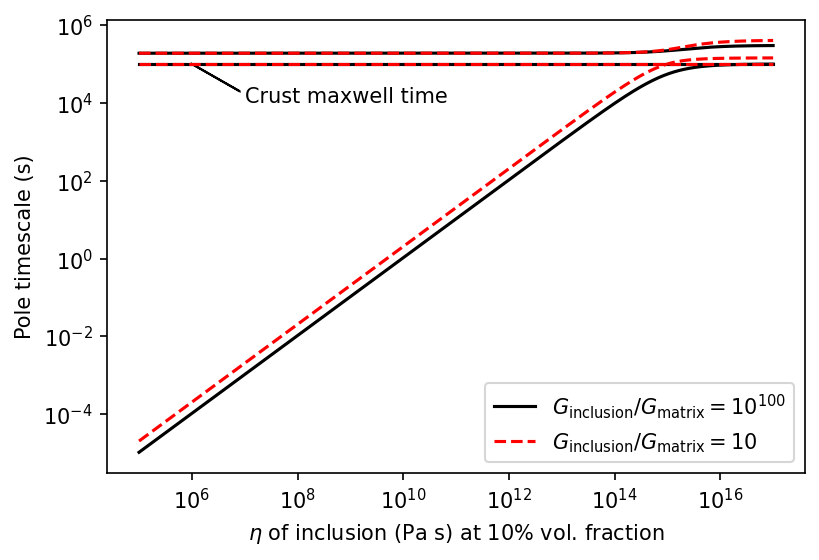

In [184]:
big_num = 1e100
K1_example = 1e10
K2_example = 1e10
G1_example = 1e10
G2_example = 1e10
eta1_example = 1e15
eta2_example = 1e5

num, den, prefactor = GMM_poly_roots(K1_example, K2_example, G1_example, big_num, eta1_example, eta2_example, 0.1)

eta2_range = np.geomspace(1e5, 1e17, 1000)
num_range = np.zeros((len(eta2_range), 3))
den_range = np.zeros((len(eta2_range), 3))
prefactor = np.zeros_like(eta2_range)
for i, eta2 in enumerate(eta2_range):
  num_range[i], den_range[i], prefactor[i] = GMM_poly_roots(K1_example, K2_example, G1_example, big_num * G1_example, eta1_example, eta2, 0.1)

plt.figure(dpi=150)

plt.loglog(eta2_range, -1/den_range[:,0], 'k', label=r"$G_\mathrm{inclusion} / G_\mathrm{matrix} = 10^{100}$")
plt.loglog(eta2_range, -1/den_range[:,1], 'k')
plt.loglog(eta2_range, -1/den_range[:,2], 'k')

for i, eta2 in enumerate(eta2_range):
  num_range[i], den_range[i], prefactor[i] = GMM_poly_roots(K1_example, K2_example, G1_example, 1*G1_example, eta1_example, eta2, 0.1)

plt.loglog(eta2_range, -1/den_range[:,0], 'r--', label=r"$G_\mathrm{inclusion} / G_\mathrm{matrix} = 10$")
plt.loglog(eta2_range, -1/den_range[:,1], 'r--')
plt.loglog(eta2_range, -1/den_range[:,2], 'r--')
plt.xlabel("$\eta$ of inclusion (Pa s) at 10% vol. fraction")
plt.ylabel("Pole timescale (s)")

plt.legend()
plt.annotate("Crust maxwell time", (1e6, 1e4), (1e7, 1e4), 'data')
plt.arrow(8e6, 2e4, -7e6, 1e5-2e4)

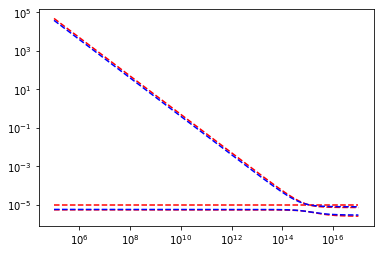

In [187]:
plt.loglog(eta2_range, -den_range[:,0], 'r--')
plt.loglog(eta2_range, -den_range[:,1], 'r--')
plt.loglog(eta2_range, -den_range[:,2], 'r--')

plt.loglog(eta2_range, -num_range[:,0], 'b--')
plt.loglog(eta2_range, -num_range[:,1], 'b--')
plt.loglog(eta2_range, -num_range[:,2], 'b--')

Additive split

For $s \neq p_i$,
$$
G(s)
=
G_\infty \frac{s (s - z_1)(s - z_2)}{(s-p_0)(s-p_1)(s-p_2)}
=
G_\infty
+ \frac{B_0}{s - p_0}
+ \frac{B_1}{s - p_1}
+ \frac{B_2}{s - p_2}
$$

In [203]:
num, den, prefactor = GMM_poly_roots(K1_example, K2_example, G1_example, 10*G1_example, eta1_example, 1e4, 0.1)


In [216]:
def compute_B_coeffs(num:np.array, den:np.array) -> np.array:
  '''
  Returns vector of coefficients B_i, where

                    prod_j (p_i - z_j)
   B_i / A = ---------------------------
              prod_{j != i} (p_i - p_j)

  are the partial fraction coefficients.
  '''
  # Compute (p_i - p_j) matrix
  diff_p = (den[:,np.newaxis] - den[np.newaxis,:])
  # Overwrite diagonals (p_i - p_j) with ones
  diff_p[np.arange(den.size), np.arange(den.size)] = 1
  # Return B_i / A
  return (den[:,np.newaxis] - num).prod(axis=1) / diff_p.prod(axis=1)

In [590]:
from matplotlib.collections import LineCollection

def varcolor_plot(x:np.array, y:np.array, c:np.array,
                  linewidth=1.0, ax=None, cmap=None, colorbar=False,
                  loglog=False):
  ''' Plot lines with variable color
   x, y, c: data with shape (data_length, n_curves).
   The last axis indexes different curves. '''
  if ax is None:
    ax = plt.gca()
  if cmap is None:
    cmap = plt.get_cmap()

  # Plot invisible curve for axis scaling
  if loglog:
    plot_handles = ax.loglog(x,y)
  else:
    plot_handles = ax.plot(x,y)
  for h in plot_handles:
    h.set_visible(False)

  if len(y.shape) == 1:
    x = x[:,np.newaxis]
    y = y[:,np.newaxis]
  elif y.size > x.size:
    if len(x.shape) == 1:
      x = x[:,np.newaxis]
    # Broadcast x to shape like y
    x = x + np.zeros_like(y)

  # Build lines for each pair of consecutive points for each curve
  line_segments = []
  for i in range(y.shape[-1]):
    # Extract (x,y) points on line
    points = np.stack((x[:,i], y[:,i],), axis=1)
    line_segments.append(np.stack((points[:-1], points[1:],), axis=1))
  # Build line collection from each pair of consecutive points
  line_collection = LineCollection(
    np.concatenate(line_segments, axis=0),
    cmap=cmap)
  # Set colorsa
  line_collection.set_array(c.T.ravel())
  line_collection.set_norm(matplotlib.colors.LogNorm(
    vmin=c.min(), vmax=c.max()))
  line_collection.set_linewidth(linewidth)
  line = ax.add_collection(line_collection)
  if colorbar:
    cbar_handle = plt.colorbar(line, ax=ax)

  return line, line_segments, c.T.ravel(), cbar_handle

Text(0.5, 1.0, 'Colorbar sampling curve')

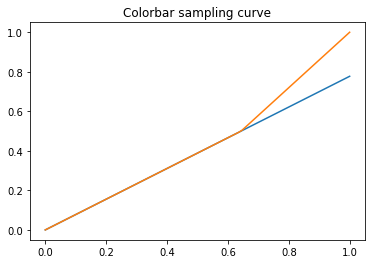

In [531]:
''' Colormap manipulation demo '''

def recenter_diverging_cmap(x, clims):
  ''' Recenters a diverging cmap so that the color-change is at zero, given
  the color limits provided by clims.
  
  Assumes that |clims[0]| > |clims[1]|, but can be generalized for the other
  case.

  Input variable x is a sampling vector taking values in [0,1].
  '''
  # Compression factor
  cn = clims / np.abs(clims).max()
  # Factor that compresses [clims[0],0] to [0, 0.5]
  # image_factor = 0.5 * (1 + (0 - cn[0]) / (cn[1] - cn[0]))
  image_factor = 0.5 * (1 - cn[1] / cn[0])

  # Maps to a subset of [0,1] by truncating
  map_truncate = image_factor * x
  # Remap unused portion of colormap to increase richness in truncated part
  # breakpoint = 1 / (1 - (cn[1] / cn[0]))
  breakpoint = 0.5 / image_factor
  # map_rescaled = (image_factor * x
  #   + ((1 - image_factor * breakpoint) / (1 - breakpoint) - image_factor)
  #     * (x - breakpoint) * (x >= breakpoint).astype(float))
  map_rescaled = image_factor * x + (0.5 * (1 - cn[0] / cn[1]) - image_factor) \
      * (x - breakpoint) * (x >= breakpoint).astype(float)

  return map_truncate, map_rescaled

color_test_x = np.linspace(0, 1, 100)
map_truncate, map_rescaled = recenter_diverging_cmap(color_test_x,
  np.array([-8.        ,  4.43478366]))
plt.plot(color_test_x, map_truncate)
plt.plot(color_test_x, map_rescaled)
plt.title("Colorbar sampling curve")

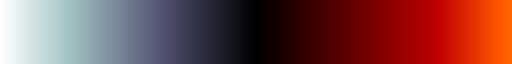

In [571]:
# Construct base diverging map

def high_constrast_div_map(t):
  # Truncate positive color map (value between 0 and 1)
  pos_color_truncation = 0.7
  pos_data_colors = matplotlib.cm.gist_heat(pos_color_truncation * (2 * t - 1))
  neg_color_truncation = 1.0
  neg_data_colors = matplotlib.cm.bone_r(neg_color_truncation * (2 * t))
  # Alpha manipulation
  neg_data_colors[:,-1] = 1 # neg_data_colors[:,0]

  cdata = (pos_data_colors * (t > 0.5).astype(float)[:,np.newaxis]
           + neg_data_colors * (t <= 0.5).astype(float)[:,np.newaxis])
  return cdata

high_contrast_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
      f'high_contrast_cmap',
      high_constrast_div_map(np.linspace(0, 1, 100)))

high_contrast_cmap

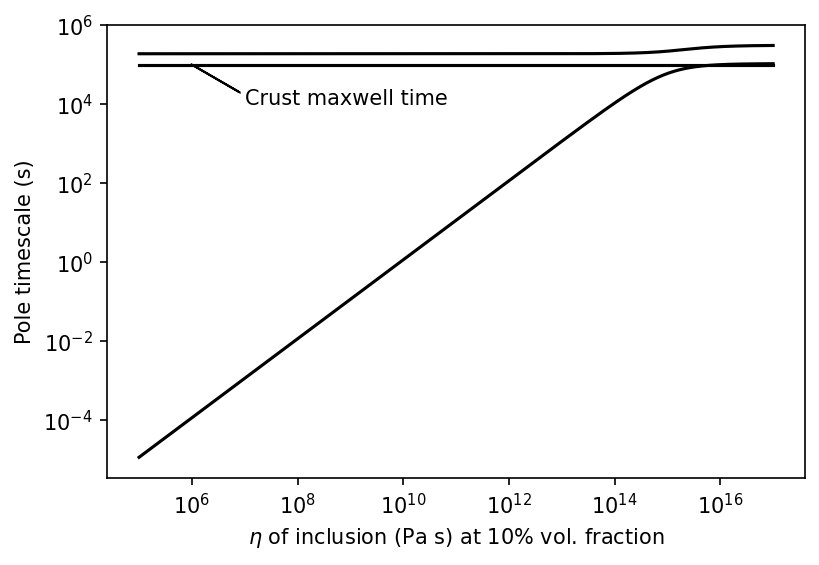

In [690]:
big_num = 1e100
K1_example = 1e10
K2_example = 1e10
G1_example = 1e10
G2_example = 10 * G1_example
eta1_example = 1e15
eta2_example = 1e5

num, den, prefactor = GMM_poly_roots(K1_example, K2_example, G1_example, big_num, eta1_example, eta2_example, 0.1)

eta2_range = np.geomspace(1e5, 1e17, 1000)
num_range = np.zeros((len(eta2_range), 3))
den_range = np.zeros((len(eta2_range), 3))
B_i_range = np.zeros((len(eta2_range), 3))
prefactor = np.zeros_like(eta2_range)

plt.figure(dpi=150)

for i, eta2 in enumerate(eta2_range):
  num_range[i], den_range[i], prefactor[i] = GMM_poly_roots(K1_example, K2_example, G1_example, G2_example, eta1_example, eta2, 0.1)
  B_i_range[i] = compute_B_coeffs(num_range[i], den_range[i])

plt.loglog(eta2_range, -1/den_range[:,0], 'k', label=r"$G_\mathrm{inclusion} / G_\mathrm{matrix} = 10$")
plt.loglog(eta2_range, -1/den_range[:,1], 'k')
plt.loglog(eta2_range, -1/den_range[:,2], 'k')

plt.xlabel("$\eta$ of inclusion (Pa s) at 10% vol. fraction")
plt.ylabel("Pole timescale (s)")

plt.annotate("Crust maxwell time", (1e6, 1e4), (1e7, 1e4), 'data')
plt.arrow(8e6, 2e4, -7e6, 1e5-2e4)

(3.4909046786490853e-06, 1015506.9693763908)

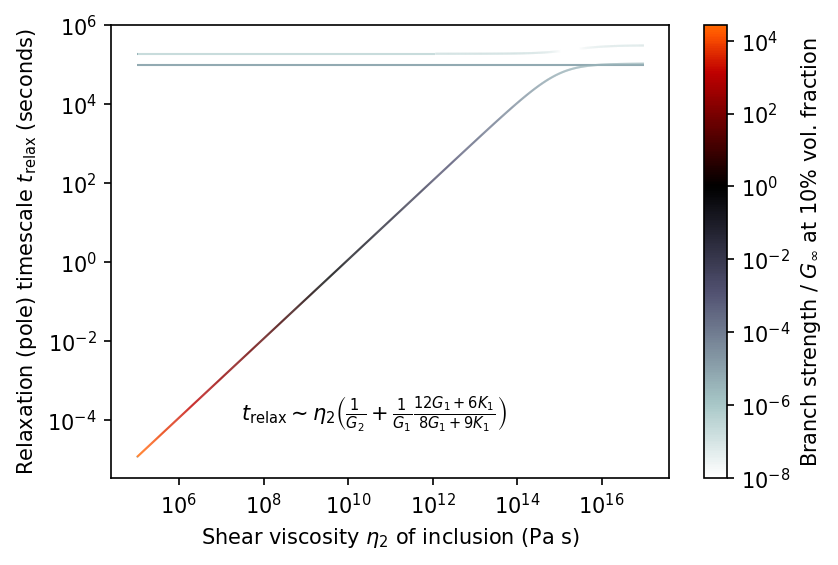

In [731]:
fig, ax = plt.subplots(dpi=150)

# Abs value of B_i / G_infty
B_abs = np.abs(B_i_range)
# Normalization
B_abs_normalized = np.abs(B_i_range) / np.abs(B_i_range).max(axis=1, keepdims=True)
# Pick color data
cdata = np.clip(B_abs[:,:], 1e-8, None)
cdata_log = np.log10(cdata)

# RGBA sample points
clims = np.array((cdata_log.min(), cdata_log.max(),))
trunc_min = 0.0
trunc_max = 0.5 * (1 + (clims[1] - 0) / (0 - (clims[0])))
# Re-centered diverging colormap sampling values (0, 1)
map_truncate, map_rescaled = recenter_diverging_cmap(
  np.linspace(0, 1, 100), clims)

use_builtin = False
if use_builtin:
  color_dat = matplotlib.cm.RdGy_r(map_rescaled)
  color_dat[:,0:3] = 1 - color_dat[:,0:3]
else:
  color_dat = high_contrast_cmap(map_rescaled)

rescaled_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
  f'rescaled_cmap',
  color_dat)

lc, dat, colordat, cbar_handle = varcolor_plot(eta2_range,
              -1/den_range[:,:],
              cdata,
              ax=ax, cmap=rescaled_cmap, colorbar=True, loglog=True)

plt.xlabel(r"Shear viscosity $\eta_2$ of inclusion (Pa s)")
plt.ylabel(r"Relaxation (pole) timescale $t_\mathrm{relax}$ (seconds)")

asymptotic_slope = 1 / G2_example + (12*G1_example + 6*K1_example) / (G1_example*(8*G1_example + 9*K1_example))
# plt.plot(eta2_range, asymptotic_slope*eta2_range, 'k:', linewidth=1)

_xlim, _ylim = plt.xlim(), plt.ylim()
# Slope triangle
tri_coordinates = np.array([
  [3e7, 1e-4,],
  [8e9, 1e-4,],
  [8e9, 0.0,],
])
# tri_coordinates[2,1] = tri_coordinates[2,0] / tri_coordinates[0,0] * tri_coordinates[0,1]
# plt.loglog(tri_coordinates[0:2,0], tri_coordinates[0:2,1], 'k', linewidth=0.75)
# plt.loglog(tri_coordinates[1:3,0], tri_coordinates[1:3,1], 'k', linewidth=0.75)
# plt.loglog(tri_coordinates[[0,2],0], tri_coordinates[[0,2],1], 'k', linewidth=0.75)

plt.annotate(r"$t_\mathrm{relax} \sim \eta_2 \left( \frac{1}{G_2} + \frac{1}{G_1} \frac{12G_1 + 6 K_1}{8G_1 + 9K_1} \right)$",
             tri_coordinates[1,:], tri_coordinates[0,:],)

# cbar_handle.ticks = matplotlib.LogFormatter(10, labelOnlyBase=False) 
# cb = plt.colorbar(ticks=[1,5,10,20,50], format=formatter)
# cbar_handle.formatter = matplotlib.ticker.LogFormatterExponent
cbar_handle.set_label("Branch strength / $G_\infty$ at 10% vol. fraction")

plt.xlim(_xlim)
plt.ylim(_ylim)

To compare to Maxwell viscoelastic:
$$
G_\mathrm{MV}(s) = \frac{Gs}{s + G/\eta} = G \left( 1 - \frac{G/\eta}{s + G/\eta} \right).
$$
To recover single-phase behaviour as $\eta_2 \geq \eta_1$, we look for a sum of branch strengths on the order of $-G/\eta$.

Curve: adding coefficients from the two significant branches; black-dashed: crust Maxwell time G/eta


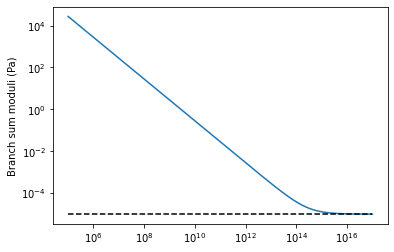

In [742]:
plt.loglog(eta2_range, -B_i_range[:,0] + -B_i_range[:,1])
plt.loglog(eta2_range, np.full_like(eta2_range, G1_example/eta1_example), 'k--')
plt.ylabel("Branch sum moduli (Pa)")
print("Curve: adding coefficients from the two significant branches; black-dashed: crust Maxwell time G/eta")

In [684]:
slope

2.0588235294117647e-10

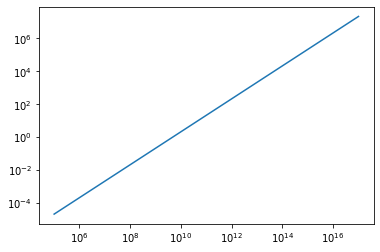

In [ ]:
# Plot asymptotic guideline
plt.loglog(eta2_range, slope*eta2_range)


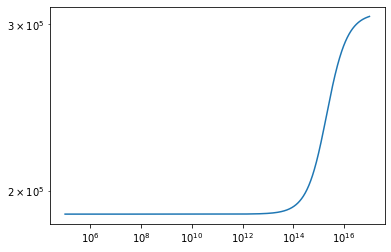

In [600]:
plt.loglog(eta2_range,
          -1/den_range[:,2])

In [ ]:
# Asymptotic den[1] expression?

# roots_den = np.array([
#     -G1/eta1,
#     -((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) + 9*G1*K1*eta2))/2 - (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
#     ((G1*((64*G1**2*G2**2*eta1**2 + 192*G1**2*G2**2*eta1*eta2 + 144*G1**2*G2**2*eta2**2 - 144*G1**2*G2*K1*eta1*eta2 + 24*G1**2*G2*K1*eta2**2 + 81*G1**2*K1**2*eta2**2 + 144*G1*G2**2*K1*eta1**2 - 24*G1*G2**2*K1*eta1*eta2 - 162*G1*G2*K1**2*eta1*eta2 + 81*G2**2*K1**2*eta1**2)**(1/2) - 9*G1*K1*eta2))/2 + (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)) - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)),
#   ])

# see next box

In [681]:
_den1 = (-( (G1*((64*G1**2*G2**2*eta1**2
        + 192*G1**2*G2**2*eta1*eta2
        + 144*G1**2*G2**2*eta2**2
        - 144*G1**2*G2*K1*eta1*eta2
        + 24*G1**2*G2*K1*eta2**2
        + 81*G1**2*K1**2*eta2**2
        + 144*G1*G2**2*K1*eta1**2
        - 24*G1*G2**2*K1*eta1*eta2
        - 162*G1*G2*K1**2*eta1*eta2
        + 81*G2**2*K1**2*eta1**2)**(1/2)
        + 9*G1*K1*eta2))/2
    - (G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*(12*G1 + 6*K1)))/(eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1))
- (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1)))


In [677]:
G1, G2, K1, K2, eta1, eta2 = (10000000000.0,
 100000000.0,
 10000000000.0,
 1000000000.0,
 100000000000000.0,
 10000.0)

In [678]:
G1, G2, K1, K2, eta1 = G1_example, G2_example, K1_example, K2_example, eta1
eta2 = 10000

In [682]:
_t0 = -(G1*((64*G1**2*G2**2*eta1**2
        + 192*G1**2*G2**2*eta1*eta2
        + 144*G1**2*G2**2*eta2**2
        - 144*G1**2*G2*K1*eta1*eta2
        + 24*G1**2*G2*K1*eta2**2
        + 81*G1**2*K1**2*eta2**2
        + 144*G1*G2**2*K1*eta1**2
        - 24*G1*G2**2*K1*eta1*eta2
        - 162*G1*G2*K1**2*eta1*eta2
        + 81*G2**2*K1**2*eta1**2)**(1/2)
        + 9*G1*K1*eta2)) / 2 / (eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1))

_t1 = +(G1*(8*G1**2 + 9*K1*G1)*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2)) \
        / ((2*(12*G1 + 6*K1)) * (eta1*eta2*(8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)))

_t2 = - (G1*(8*G1*eta1 + 12*G1*eta2 + 9*K1*eta1 + 12*K1*eta2))/(2*eta1*eta2*(12*G1 + 6*K1))
_t0, _t1, _t2, _t0 + _t1 + _t2, _den1

(-242857.1428642016,
 229365.0793974603,
 -472222.2222888889,
 -485714.2857556302,
 -485714.2857556302)

In [683]:
# Asymptotic expression: intermediate calculations

_s0 = -0.5 * G1 * (64*G1**2*G2**2
        + 144*G1*G2**2*K1
        + 81*G2**2*K1**2)**(1/2) / ((8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1))

_s1 = +(G1*(8*G1**2 + 9*K1*G1)*(8*G1 + 9*K1)) \
        / (2*(12*G1 + 6*K1) * (8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1))

_s2 = -(G1*(8*G1 + 9*K1))/(2*(12*G1 + 6*K1))

_s1s2 = - 0.5 * G1 * G2 * (8*G1 + 9*K1) / (8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)

_sum = - G1 * G2 * (8*G1 + 9*K1) / (8*G1**2 + 12*G1*G2 + 9*G1*K1 + 6*G2*K1)

_sum_recip = -1 / G2 - (12*G1 + 6*K1) / (G1*(8*G1 + 9*K1))

_s0 / eta2, _s1 / eta2, _s2 / eta2, _s1s2 / eta2, (_s1 + _s2) / eta2, (_s0 + _s1 + _s2) / eta2, _sum/eta2, 1/_sum_recip/eta2

(-242857.14285714284,
 229365.07936507935,
 -472222.22222222225,
 -242857.14285714284,
 -242857.14285714287,
 -485714.2857142857,
 -485714.2857142857,
 -485714.28571428574)

For $\eta_2 \ll \eta_1$, i.e., viscous inclusions, the asymptotic expression for the shortest timescale $-s^{-1}_\mathrm{visc}$ is
$$
-s^{-1}_\mathrm{visc} = \eta_2 \left( G_2^{-1} + G_1^{-1} \frac{12G_1 + 6 K_1}{8G_1 + 9K_1} \right),
$$
independent of the volume fraction $\phi_2$. The magnitude of the viscoelastic ``branch" corresponding to this timescale depends on $\phi_2$.

In [689]:
1 / (eta2 * (1 / G2_example + (12*G1_example + 6*K1_example) / (G1_example*(8*G1_example + 9*K1_example))))

485714.28571428574